Курсовая работа

In [1]:
!pip install wordcloud

In [259]:
!pip install pingouin

In [1]:
import pandas as pd  # работа с табличными данными и их анализ
from scipy import stats  # статистические тесты и функции
from math import sqrt  # вычисление квадратного корня
from scipy.stats import chi2_contingency  # Хи-квадрат
import matplotlib.pyplot as plt  # построение графиков и визуализация
import seaborn as sns  # продвинутые статистические визуализации
from scipy.stats import pointbiserialr # корреляция для бинарных данных 
from scipy.stats import norm  # нормальное распределение
import numpy as np  # работа с массивами и числовыми операциями
from wordcloud import WordCloud  # облако слов
import pingouin as pg  # Q-Q Plot и частная корреляция
import warnings
import json
from scipy.stats import pearsonr, spearmanr
warnings.filterwarnings('ignore')  # отключаем предупреждения для чистого вывода

Дататсет с портала Работа России с вакансиями по всем регионам России по состоянию на февраль 2026 года. Ниже описание признаков из датасета.

| № | Название признака | Назначение | Описание |
|---|------------------------------|------------|----------|
| 1 | vacancyName | Наименование вакансии | Наименование вакансии |
| 2 | codeProfession | Код профессии | Код профессии из справочника профессий dict_profession (поле code) |
| 3 | codeProfessionalSphere | Код профессиональной сферы | Код (англоязычное название) профессиональной сферы из справочника dict_professional_sphere (поле code) |
| 4 | professionalSphereName | Наименование профессиональной сферы | Наименование (англоязычное название) профессиональной сферы из справочника dict_professional_sphere (поле name) |
| 5 | salary | Заработная плата | salaryMin – минимальный размер; salaryMax – максимальный размер |
| 6 | socialProtecteds | Группа соц. защищенности | socialProtectedIds (id), socialProtected (name) из dict_social_protected |
| 7 | languageKnowledge | Знание языков | codeLanguage, idOwner, isModerated, isPreferred, level, type |
| 8 | busyType | Тип занятости | FULL, PARTIAL, PROJECT, PROBATION, SEASONAL, REMOTE |
| 9 | educationRequirements | Требования к образованию | NULL, MIDDLE, MIDDLE_SPECIAL, UNFINISHED_HIGH, HIGH |
|10 | speciality | Специалитет | — |
|11 | academicDegree | Ученая степень | — |
|12 | hardSkills | Профессиональные навыки | hardSkillName |
|13 | softSkills | Гибкие навыки | hardSkillName |
|14 | experienceRequirements | Требуемый опыт | Количество лет |
|15 | qualifications | Квалификация | Степень и уровень проф. подготовленности |
|16 | professionalSphereName | Наименование профессиональной сферы | dict_professional_sphere (external_id) |
|17 | scheduleType | График работы | FULL, TURN, FLOAT, WATCH, IRREGULAR, PART_TIME |
|18 | premium | Премия | premiumSize, premiumType (ANNUAL, QUARTERLY, MONTHLY), bonusType (RUB, PERCENT) |
|19 | otherVacancyBenefit | Дополнительные бонусы | Заполняется вручную |
|20 | id | Идентификатор вакансии | Идентификатор вакансии |
|21 | careerPerspective | Карьерный рост | true / false |
|22 | codeExternalSystem | Код внешней системы | SKILLSNET, CZN, ABILYMPICS, ENUM, RESUME, TEMPLATE |
|23 | idPriorityCategory | Категория приоритетности | Признак «Опытные кадры» (true / false) |
|24 | needMedcard | Медицинская книжка | требуется / не требуется / не указано |
|25 | sourceType | Тип источника вакансии | RECRUITMENT_AGENCY, COMPANY, CHAZ, EMPLOYMENT_SERVICE, HR_SERVICE, RPORTAL, FROM_ESIA, INTERNET_RESOURCE |
|26 | requiredCertificates | Сертификаты | Заполняется вручную |
|27 | requiredDriveLicense | Водительские права | A, B, C, D, E |
|28 | retrainingCapability | Возможность переобучения | true / false |
|29 | retrainingCondition | Условия переобучения | Текстовое поле |
|30 | retrainingGrantValue | Оплата во время обучения | Да |
|31 | transportCompensation | Транспортные расходы | FUEL_PAID, PASSAGE_PAID, AUTO |
|32 | changeTime | Время изменения | ГГГГ-ММ-ДД ЧЧ:ММ:СС |
|33 | contactPerson | Контактное лицо | ФИО |
|34 | contactSource | Источник контактов | — |
|35 | company | Информация о компании | code, inn, email, phone, site, ogrn и др. |
|36 | fullCompanyName | Полное наименование компании | — |
|37 | oknpoCode | ОКНПО | — |
|38 | oksoCode | ОКСО | — |
|39 | companyBusinessSize | Размер компании | SMALL, MICRO, MIDDLE, BIG, LARGE |
|40 | dateModify | Дата изменения | ГГГГ-ММ-ДД ЧЧ:ММ:СС |
|41 | workPlaces | Рабочие места | Количество |
|42 | isUzbekistanRecruitment | Оргнабор Узбекистан | true / false |
|43 | federalDistrictCode | Федеральный округ | Код |
|44 | industryBranchName | Отрасль | dict_industry_branch |
|45 | datePublished | Дата публикации | ГГГГ-ММ-ДД |
|46 | accommodationCapability | Возможность переезда | true / false / не указано |
|47 | accommodationType | Тип жилья | NULL, FLAT, ROOM, DORMITORY, HOUSE |
|48 | foreignWorkersCapability | Найм нерезидентов | true / false |
|49 | isQuoted | Квотируемая вакансия | true / false |
|50 | creationDate | Дата создания | ГГГГ-ММ-ДД ЧЧ:ММ:СС |
|51 | deleted | Признак удаления | true / false |
|52 | visibility | Видимость | HIDDEN, VISIBLE_TO_ALL |
|53 | regionName | Регион | — |
|54 | status | Статус вакансии | WAITING, ACCEPTED, CHANGED, REJECTED |
|55 | vacancyUrl | Ссылка на вакансию | URL |
|56 | positionRequirements | Должностные требования | Текст |
|57 | isMobilityProgram | Программа мобильности | true / false |
|58 | isModerated | Модерация | true / false |
|59 | metroIds | Станции метро | dict_metro |
|60 | vacancyAddress | Адрес | Область, город |
|61 | vacancyAddressHouse | Дом | — |
|62 | vacancyAddressAdditionalInfo | Адрес (доп.) | Доп. информация |
|63 | geo | Геокоординаты | longitude, latitude |


# 1. Описание датасета <a class="anchor" id="chapter1"></a>

In [2]:
df = pd.read_csv('vacancy.csv', sep='|', on_bad_lines='skip')

Посмотрим на данные. 

In [3]:
pd.set_option('display.max_columns', None)  # показываем все колонки
df

,id,stateRegionCode,vacancyName,codeProfession,codeProfessionalSphere,professionalSphereName,vacancyAddress,vacancyAddressHouse,vacancyAddressAdditionalInfo,geo,salary,socialProtecteds,languageKnowledge,busyType,educationRequirements,hardSkills,softSkills,skills,typicalPosition,experienceRequirements,scheduleType,premium,otherVacancyBenefit,careerPerspective,codeExternalSystem,idPriorityCategory,needMedcard,sourceType,requiredСertificates,requiredDriveLicense,retrainingCapability,retrainingСondition,retrainingGrantValue,transportCompensation,changeTime,contactPerson,contactSource,company,fullCompanyName,oknpoCode,oksoCode,companyBusinessSize,dateModify,workPlaces,isUzbekistanRecruitment,federalDistrictCode,industryBranchName,datePublished,accommodationCapability,accommodationType,foreignWorkersCapability,metroIds,isQuoted,creationDate,isMobilityProgram,isModerated,deleted,visibility,regionName,status,vacancyUrl,positionRequirements,contactList,additionalRequirements,salaryMin,salaryMax,qualifications,responsibilities,addressCode,addressOffice,hireDate,workPlace,medicalCertificate,scheduleTypeComment,benefitDetails,trainingDays,shift,medicalDocument,benefit,conditions
0,97828f48-b645-11f0-a6f2-2765e1722204,5800000000000,Электромонтер по обслуживанию подстанций,198423.0,ElectricpowerIndustry,Электроэнергетика,"Пензенская область, Город Пенза, Аустрина улиц...",168,NaN,"{""latitude"": 53.253454, ""longitude"": 45.013555}",от 30691,Инвалид,[],Полная занятость,"{""educationType"": ""Среднее профессиональное об...",[],[],[],Электромонтажник / Электромонтер,0,Сменная работа,{},NaN,False,NaN,NaN,Не указано,Работодатель,NaN,[],NaN,NaN,NaN,NaN,2025-10-31T13:37:25+0300,Куликов Сергей Александрович,NaN,"{""companyCode"": ""b6a6b6a0-7ea7-11ec-b264-550ed...","ФИЛИАЛ ПУБЛИЧНОГО АКЦИОНЕРНОГО ОБЩЕСТВА ""РОССЕ...",NaN,2130302,SMALL,2025-11-11T16:34:14+0300,13,False,4.0,NaN,2025-11-11T16:34:14+0300,False,NaN,False,NaN,False,2025-10-31T13:37:25+0300,NaN,True,False,Видно всем,Пензенская область,Одобрено,https://trudvsem.ru/vacancy/card/b6a6b6a0-7ea7...,профессиональное обучение по программам профес...,"[{""contactType"": ""Телефон"", ""contactValue"": ""+...",NaN,30691,43252,профессиональное обучение по программам профес...,- оперативно-эксплуатационное обслуживание ПС ...,58000001000003800.0,NaN,NaN,"{""workPlaceDisabilityGroup"": ""Общее заболевани...",NaN,NaN,NaN,0,"[""По графику сменности""]",NaN,Добровольное медицинское страхование,Допустимые
1,94025018-684f-11f0-98c4-d549be31d974,7200000000000,Техник-дозиметрист отдела радиационной безопас...,269277.0,Medicine,Здравоохранение и социальное обеспечение,"Тюменская область, Город Тюмень, Юрия Семовски...",14,NaN,"{""latitude"": 57.099834, ""longitude"": 65.548359}",от 42000,NaN,[],Полная занятость,"{""educationType"": ""Среднее профессиональное об...",[],[],[],Ничего не выбрано,0,Полный рабочий день,{},NaN,False,NaN,NaN,Не указано,Работодатель,NaN,[],NaN,NaN,NaN,NaN,2025-07-24T08:32:38+0300,Григорьева Наталья Александровна,NaN,"{""companyCode"": ""d4004160-74c4-11ea-ace8-e37b4...",ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ УЧРЕЖДЕНИЕ ЗДРАВООХ...,NaN,NaN,LARGE,2025-10-20T07:19:11+0300,1,False,5.0,NaN,2025-10-20T07:19:11+0300,False,NaN,False,NaN,False,2025-07-24T08:32:24+0300,NaN,True,False,Видно всем,Тюменская область,Одобрено,https://trudvsem.ru/vacancy/card/d4004160-74c4...,среднее профессиональное техническое образован...,"[{""contactType"": ""Телефон"", ""contactValue"": ""+...",NaN,42000,45000,среднее профессиональное техническое образован...,Осуществлять контроль за мощностью дозы гамма-...,72000001000172400.0,NaN,NaN,"{""workPlaceForeign"": false, ""workPlaceOrdinary...",NaN,NaN,NaN,0,[],Медицинская книжка,NaN,NaN
2,92f939f4-d149-11f0-8275-113a9df2fe29,2600000000000,Специалист по кредитованию,NaN,Transport,"Транспорт, автобизнес, логистика, склад, ВЭД","Ставропольский край, Минераловодский район, Го...",NaN,NaN,"{""latitude"": 44.208806, ""longitude"": 43.13834}",от 0,NaN,[],Полная занятость,"{""education

Для курсовой работы меня будут интересовать вакансии с меткой socialProtecteds = несовершеннолетние работники. Поэтому создаю новый датасет на основе исходного, где будут хранится вакансии с признаком несовершеннолетних.

In [4]:
dff = df[
    df['socialProtecteds'].str.contains('несовершеннолетние работники', na=False, case=False)
]

dff.head()

,id,stateRegionCode,vacancyName,codeProfession,codeProfessionalSphere,professionalSphereName,vacancyAddress,vacancyAddressHouse,vacancyAddressAdditionalInfo,geo,salary,socialProtecteds,languageKnowledge,busyType,educationRequirements,hardSkills,softSkills,skills,typicalPosition,experienceRequirements,scheduleType,premium,otherVacancyBenefit,careerPerspective,codeExternalSystem,idPriorityCategory,needMedcard,sourceType,requiredСertificates,requiredDriveLicense,retrainingCapability,retrainingСondition,retrainingGrantValue,transportCompensation,changeTime,contactPerson,contactSource,company,fullCompanyName,oknpoCode,oksoCode,companyBusinessSize,dateModify,workPlaces,isUzbekistanRecruitment,federalDistrictCode,industryBranchName,datePublished,accommodationCapability,accommodationType,foreignWorkersCapability,metroIds,isQuoted,creationDate,isMobilityProgram,isModerated,deleted,visibility,regionName,status,vacancyUrl,positionRequirements,contactList,additionalRequirements,salaryMin,salaryMax,qualifications,responsibilities,addressCode,addressOffice,hireDate,workPlace,medicalCertificate,scheduleTypeComment,benefitDetails,trainingDays,shift,medicalDocument,benefit,conditions
3234,eeaddde8-f5d0-11f0-ba7d-9959eb3311ba,3100000000000,Уборщик территорий,192624.0,Education,"Образование, наука","Белгородская область, Город Губкин, Мичурина у...",дом: ЗД. 21;,NaN,"{""latitude"": 51.28298, ""longitude"": 37.529349}",от 27100,Несовершеннолетние работники,[],Временная,"{""educationType"": ""Tребования не предъявляются""}",[],[],[],Дворник,0,Неполный рабочий день/неполная рабочая неделя,{},NaN,False,NaN,NaN,Не указано,Работодатель,NaN,[],NaN,NaN,NaN,NaN,2026-01-20T10:23:35+0300,Хворова Ульяна Михайловна,NaN,"{""companyCode"": ""1023102263788"", ""url"": ""https...",ОБЛАСТНОЕ ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ ПРОФЕССИО...,NaN,NaN,SMALL,2026-01-20T10:27:29+0300,1,False,1.0,NaN,2026-01-20T10:25:05+0300,False,NaN,False,NaN,False,2026-01-20T10:23:35+0300,NaN,True,False,Видно всем,Белгородская область,Одобрено,https://trudvsem.ru/vacancy/card/1023102263788...,"Добросовестность, ответственность","[{""contactType"": ""Телефон"", ""contactValue"": ""+...",NaN,27100,27100,"Добросовестность, ответственность",Уборка прилегающей территории,31000004000019800.0,NaN,NaN,"{""workPlaceForeign"": false, ""workPlaceOrdinary...",справка об отсутствии судимости,NaN,NaN,0,[],Медицинская справка,NaN,Оптимальные
7232,74fb9f78-f533-11f0-a027-0dd543315e5a,5200000000000,помощник распределителя работ,177874.0,Industry,Производство,"Нижегородская область, Город Нижний Новгород, ...",дом: Д.5;,NaN,"{""latitude"": 56.250627, ""longitude"": 43.976396}",от 28000,Несовершеннолетние работники,[],Полная занятость,"{""educationType"": ""Tребования не предъявляются""}",[],[],"[""Ведение документации"", ""Навык работы с Micro...",Распределитель работ,0,Полный рабочий день,{},NaN,False,NaN,NaN,Не указано,Работодатель,NaN,[],NaN,NaN,NaN,NaN,2026-01-19T15:45:50+0300,Киреева Наталья Витальевна,NaN,"{""companyCode"": ""1085261002628"", ""url"": ""https...","АКЦИОНЕРНОЕ ОБЩЕСТВО ""ФЕДЕРАЛЬНЫЙ НАУЧНО-ПРОИЗ...",NaN,NaN,SMALL,2026-01-19T15:58:09+0300,3,False,4.0,NaN,2026-01-19T15:58:08+0300,False,NaN,False,NaN,False,2026-01-19T15:36:20+0300,NaN,True,False,Видно всем,Нижегородская область,Одобрено,https://trudvsem.ru/vacancy/card/1085261002628...,"дисциплинированность, ответственность","[{""contactType"": ""Телефон"", ""contactValue"": ""+...",NaN,28000,35000,"дисциплинированность, ответственность",Внесение информации в информационные базы данных,52000001000123200.0,NaN,NaN,"{""workPlaceForeign"": false, ""workPlaceOrdinary...",о допуске к к работе от профпатолога,NaN,NaN,0,[],Медицинская справка,NaN,Допустимые
18048,0bb2daf0-e166-11f0-a6fd-690b9f9d74c0,5200000000000,Гардеробщик,116334.0,Culture,"Искусство, культура и развлечения","Нижегородская область, Город Дзержинск, Ленина...",дом: 62;,NaN,"{""latitude"": 56.237197, ""longitude"": 43.456541}",от 27093,Несовершеннолетние работники,[],Полная занятос

Выведем информацию о датасете.

In [5]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2215 entries, 3234 to 491035
Data columns (total 80 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            2215 non-null   object 
 1   stateRegionCode               2215 non-null   int64  
 2   vacancyName                   2215 non-null   object 
 3   codeProfession                2211 non-null   float64
 4   codeProfessionalSphere        2215 non-null   object 
 5   professionalSphereName        2215 non-null   object 
 6   vacancyAddress                2214 non-null   object 
 7   vacancyAddressHouse           2200 non-null   object 
 8   vacancyAddressAdditionalInfo  561 non-null    object 
 9   geo                           2215 non-null   object 
 10  salary                        2215 non-null   object 
 11  socialProtecteds              2215 non-null   object 
 12  languageKnowledge             2215 non-null   object 
 13  bus

Много данных, которые должны быть числовыми - категориальные, далее я буду их обрабатывать. Например: geo, salary, salaryMin, salaryMax и другие на которые я посмотрю в ходе работы дальше.

In [6]:
dff.shape  # число строк и столбцов

(2215, 80)

У нас 2215 объектов и 80 признаков. Выведем столбцы, содержащие более 5% пропусков, с указанием процента пустых значений.

In [7]:
empty_pct = dff.isna().mean() * 100
empty_pct = empty_pct[empty_pct > 5].sort_values(ascending=False).reset_index()
empty_pct.columns = ['Столбец', 'Процент пустых значений']
empty_pct.style.format({'Процент пустых значений': '{:.2f}%'}).hide(axis='index')

Столбец,Процент пустых значений
industryBranchName,100.00%
requiredСertificates,100.00%
retrainingСondition,100.00%
oknpoCode,100.00%
idPriorityCategory,99.95%
retrainingGrantValue,99.73%
benefitDetails,99.73%
contactSource,99.59%
metroIds,99.59%
oksoCode,99.50%


<Axes: >

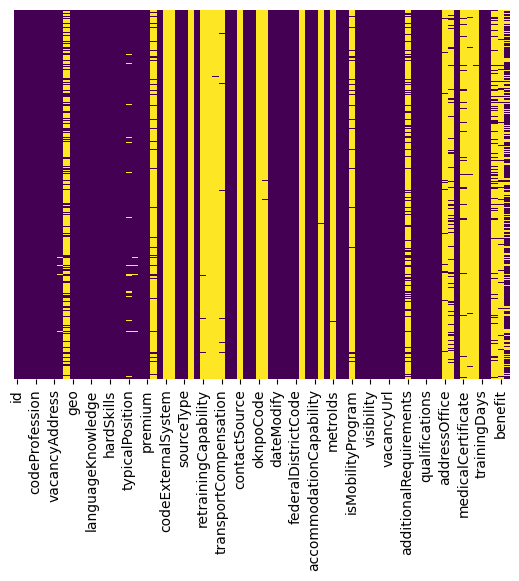

In [8]:
sns.heatmap(dff.isnull(),yticklabels=False,cbar=False,cmap='viridis')

Есть практически пустые столбцы, которые сы не можем использовать в дальнейшем использовании, поэтому я их удаляю. 

In [9]:
cols_to_drop = [
    'industryBranchName',
    'requiredСertificates', 
    'retrainingСondition',
    'oknpoCode',
    'idPriorityCategory',
    'retrainingGrantValue',
    'benefitDetails',
    'contactSource',
    'metroIds',
    'oksoCode',
    'codeExternalSystem',
    'accommodationType',
    'scheduleTypeComment',
    'retrainingCapability',
    'transportCompensation',
    'addressOffice',
    'medicalCertificate',
    'benefit',
    'isMobilityProgram',
    'otherVacancyBenefit',
    'hireDate',
    'medicalDocument',
    'additionalRequirements',
    'vacancyAddressAdditionalInfo',
    'conditions'
]

dff.drop(columns=cols_to_drop, inplace=True)

In [10]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2215 entries, 3234 to 491035
Data columns (total 55 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        2215 non-null   object 
 1   stateRegionCode           2215 non-null   int64  
 2   vacancyName               2215 non-null   object 
 3   codeProfession            2211 non-null   float64
 4   codeProfessionalSphere    2215 non-null   object 
 5   professionalSphereName    2215 non-null   object 
 6   vacancyAddress            2214 non-null   object 
 7   vacancyAddressHouse       2200 non-null   object 
 8   geo                       2215 non-null   object 
 9   salary                    2215 non-null   object 
 10  socialProtecteds          2215 non-null   object 
 11  languageKnowledge         2215 non-null   object 
 12  busyType                  2215 non-null   object 
 13  educationRequirements     2215 non-null   object 
 14  hardSkil

In [11]:
dff.to_csv('school_vacancies.csv', index=False, encoding='utf-8-sig')

Cохраняю датасет в новый файл

In [12]:
dff.duplicated().sum()

np.int64(0)

Дубликатов совсем нет.

# 1.1 Подготовка датасета к дальнейшему исследованию <a class="anchor" id="chapter1"></a>

Так как числовых значений нет, сразу начинаю обрабатывать датасет, чтобы смотреть описательные статистики.

In [13]:
dff['salary'].unique()[:100]

array(['от 27100', 'от 28000', 'от 27093', 'от 27903', 'от 28571',
       'от 6800', 'от 35220', 'от 63000', 'от 30000', 'от 1500',
       'от 31157', 'от 35904', 'от 22440', 'от 35000', 'от 6784',
       'от 10000', 'от 25500', 'от 1000', 'от 29573', 'от 15000',
       'от 10132', 'от 46000', 'от 38000', 'от 27500', 'от 27000',
       'от 13720', 'от 20000', 'от 17000', 'от 8800', 'от 45000',
       'от 27150', 'от 40000', 'от 31165', 'от 33867', 'от 43348',
       'от 6773', 'от 33587', 'от 32000', 'от 27400', 'от 23610',
       'от 27700', 'от 13547', 'от 41000', 'от 36000', 'от 31334',
       'от 29000', 'от 27120', 'от 29200', 'от 28334', 'от 30642',
       'от 33000', 'от 14820', 'от 35221', 'от 43350', 'от 45540',
       'от 13546', 'от 32980', 'от 20990', 'от 3806', 'от 37930',
       'от 31900', 'от 15579', 'от 34000', 'от 14901', 'от 30457',
       'от 37000', 'от 6774', 'от 30005', 'от 60000', 'от 50000',
       'от 13464', 'от 13600', 'от 28254', 'от 19000', 'от 23000',
   

Мешает приставка от, которая делает из инта в обджект, ее убираем

In [14]:
dff['salary'].dtype

dtype('O')

0 потому что видимо есть и NaN значения

In [15]:
dff['salary'] = dff['salary'].str.replace('от ', '', regex=False).astype(float)

In [16]:
dff['salary'] = pd.to_numeric(dff['salary'], errors='coerce').astype('Int64')
dff['salary'] = dff['salary'].astype('Int64')

In [17]:
dff['salary'].isna().sum()

np.int64(0)

Получилось, далее делаю тоже самое и с минимальной и максимальной зарплатой

In [19]:
dff['salaryMin'].unique()[:100]

array([27100, 28000, 27093, 27903, 28571, 6800, 35220, 63000, 30000, 1500,
       31157, 35904, 22440, 35000, 6784, 10000, 25500, 1000, 29573,
       15000.0, 10132.0, 46000.0, 38000.0, 27500.0, 27000.0, 13720.0,
       20000.0, 17000, 8800, 45000, 27150, 40000, 31165, 33867, 43348,
       6773, 33587, 32000, 27400, 23610, 27700, 13547, 41000, 36000,
       31334, 29000, 27120, 29200, 28334, 30642, 33000, 14820, 35221,
       43350, 45540, 13546, 32980, 20990, 3806, 37930, 31900, 15579,
       34000, 14901, 30457, 37000, 6774, 30005, 60000, 50000, 13464,
       13600, 28254, 19000, 23000, 31200, 20320, 13550, 34832, 5118,
       25976, 7682, 102000, 9500, 17800, 37715, 25602, 33875, 40640,
       100000, 13591, 38600, 25787, 18970, 43349, 51500, 27800, 25000,
       51856, 33660], dtype=object)

In [20]:
dff['salaryMin'] = pd.to_numeric(dff['salaryMin'], errors='coerce').astype('Int64')
dff['salaryMin'] = dff['salaryMin'].astype('Int64')

In [22]:
dff['salaryMin'].dtype

Int64Dtype()

In [23]:
dff['salaryMax'] = pd.to_numeric(dff['salaryMax'], errors='coerce').astype('Int64')
dff['salaryMax'] = dff['salaryMax'].astype('Int64')

In [24]:
dff['salaryMax'].dtype

Int64Dtype()

In [25]:
dff['salaryMax'].unique()[:100]

<IntegerArray>
[ 27100,  35000,  27093,  27903,  28571,   6800,  27200,  35220,  63000,
  30000,   2000,  31157,  35904,  22440,  45000,   6784,  33660,  26000,
  38500,  29573,  10132,  10000,  46000,  38000,  28000,  13720,  25000,
  17000,   9000,  27150,  65000,  40000,  31165,  33867,  43348,   6773,
  33587,  32000,  27400,  23610,  27700,  80000,  55461,  50000,  27120,
  29200,  36500,  31000,  28334,  30642,  33000,  29640, 150000,  35221,
  43350,  34700,  13547,  12000,  43349,  13546,  32980,  20990,   3806,
  37930,  34000,  14901,  37931,  30457,  36000,  35508,   6774,  30005,
  70000,  43000,  29000, 100000,  13464,  30500,  13600,  19000,  15579,
  23000,  31200,  20320,  13550,  34832,   5118,  25976,  27094,   7682,
 102000,  55000,  37000,   9500,  17800,  37715,  37337,  15000,  33875,
  40640]
Length: 100, dtype: Int64

In [26]:
dff['workPlaces'].unique()[:100]

array(['1', '3', 1, 2, 6, 3, 44, 10, 4, 22, 60, 13, 7, 5, 8, 200, 35, 16,
       9, 15, 21, 20, 31, 25, 19, 24, 65, 17, 32, 61, 11, 18, 100, 117,
       27, 39, 12, 30, 78, 99, 14, 23, '2', '13', '46', '7', '4', '10',
       '8', '5', 103, '11', '40', '36', '20', 40, 43, 45, 50, 80, '9',
       '22', '6', '30', 300, '12', 36], dtype=object)

In [27]:
dff['workPlaces'] = pd.to_numeric(dff['workPlaces'], errors='coerce').astype('Int64')
dff['workPlaces'] = dff['workPlaces'].astype('Int64')

In [28]:
dff['geo'].unique()[:10]

array(['{"latitude": 51.28298, "longitude": 37.529349}',
       '{"latitude": 56.250627, "longitude": 43.976396}',
       '{"latitude": 56.237197, "longitude": 43.456541}',
       '{"latitude": 55.320565, "longitude": 42.151576}',
       '{"latitude": 52.133137, "longitude": 40.824028}',
       '{"latitude": 54.752692, "longitude": 32.032342}',
       '{"latitude": 52.70458, "longitude": 41.473986}',
       '{"latitude": 56.151928, "longitude": 44.1928}',
       '{"latitude": 57.460316, "longitude": 45.791936}',
       '{"latitude": 53.931907, "longitude": 32.811262}'], dtype=object)

Здесь числа должны быть типа float, сейчас они выглядят как словарик, я планирую строить визуализацию на карте, поэтому лучше выделю признаки широты и долготы в отдельные столбцы. Для этого пишу функцию: 

In [29]:
def parse_geo(geo_str):
    if pd.isna(geo_str):
        return pd.Series([None, None])
    try:
        geo_dict = json.loads(geo_str.replace("'", '"'))
        return pd.Series([geo_dict.get('latitude'), geo_dict.get('longitude')])
    except:
        return pd.Series([None, None])

dff[['latitude', 'longitude']] = dff['geo'].apply(parse_geo)

dff['latitude'] = pd.to_numeric(dff['latitude'], errors='coerce')
dff['longitude'] = pd.to_numeric(dff['longitude'], errors='coerce')

In [30]:
dff[['geo', 'latitude', 'longitude']].head()

,geo,latitude,longitude
3234,"{""latitude"": 51.28298, ""longitude"": 37.529349}",51.282980,37.529349
7232,"{""latitude"": 56.250627, ""longitude"": 43.976396}",56.250627,43.976396
18048,"{""latitude"": 56.237197, ""longitude"": 43.456541}",56.237197,43.456541
20076,"{""latitude"": 55.320565, ""longitude"": 42.151576}",55.320565,42.151576
21882,"{""latitude"": 52.133137, ""longitude"": 40.824028}",52.133137,40.824028


In [31]:
dff[['latitude', 'longitude']].dtypes

latitude     float64
longitude    float64
dtype: object

In [32]:
dff['educationRequirements'].unique()

array(['{"educationType": "Tребования не предъявляются"}',
       '{"educationType": "Общее образование"}',
       '{"educationType": "Среднее профессиональное образование"}',
       '{"educationType": "Не указано"}',
       '{"educationType": "Tребования не предъявляются", "educationSpeciality": "Образование и педагогические науки"}',
       '{"educationType": "Среднее общее образование"}',
       '{"educationType": "Высшее образование — подготовка кадров высшей квалификации"}',
       '{"educationType": "Tребования не предъявляются", "educationSpeciality": "повар"}',
       '{"educationType": "Общее образование", "educationSpeciality": "Педагогика и методика дошкольного образования"}',
       '{"educationType": "Общее образование", "educationSpeciality": "уборщик"}',
       '{"educationType": "Tребования не предъявляются", "educationSpeciality": "Организация воспитательной деятельности"}',
       '{"educationType": "Общее образование", "educationSpeciality": "Библиотечно-информационн

Выглядит не очень, должна быть номинальная шкала, поэтому применяю маппинг для преобразования 

In [33]:
edu_mapping = {
    'Tребования не предъявляются': 'NULL',
    'Не указано': 'NULL',
    'Общее образование': 'MIDDLE',
    'Среднее общее образование': 'MIDDLE',
    'Основное общее': 'MIDDLE',
    'Среднее профессиональное образование': 'MIDDLE_SPECIAL',
    'Высшее образование — бакалавриат': 'UNFINISHED_HIGH',
    'Высшее образование — специалитет, магистратура': 'HIGH',
    'Высшее образование — подготовка кадров высшей квалификации': 'HIGH'
}

def parse_education(edu_str):
    if pd.isna(edu_str):
        return pd.Series(['NULL', None])
    
    try:
        edu_dict = json.loads(edu_str.replace("'", '"'))
        edu_type = edu_dict.get('educationType', 'NULL')
        edu_clean = edu_mapping.get(edu_type, 'NULL')
        specialty = edu_dict.get('educationSpeciality')
        
        if specialty in ['не требуется', 'Не требуется', '', None]:
            specialty = None
            
        return pd.Series([edu_clean, specialty])
        
    except:
        return pd.Series(['NULL', None])
        
dff[['educationRequirements_clean', 'specialty']] = dff['educationRequirements'].apply(parse_education)

In [34]:
dff['educationRequirements'] = dff['educationRequirements_clean']

dff = dff.drop('educationRequirements_clean', axis=1)

dff['educationRequirements'].value_counts()

educationRequirements
NULL               1498
MIDDLE              626
MIDDLE_SPECIAL       83
UNFINISHED_HIGH       6
HIGH                  2
Name: count, dtype: int64

In [35]:
dff['experienceRequirements'].unique()[:100]

array(['0', 0.0, 1.0, 18.0, 3.0, nan, '16', '2', '1', 2.0, 16.0, 14.0],
      dtype=object)

Хоть их и мало, но значения неоднородные , делаю из них числа.

In [36]:
dff['experienceRequirements'] = pd.to_numeric(dff['experienceRequirements'], errors='coerce')
dff['experienceRequirements'] = dff['experienceRequirements'].fillna(0).astype(int)

dff['experienceRequirements'].dtype

dtype('int64')

In [37]:
dff['premium'].value_counts()

premium
{}                                                    2095
{"premiumSize": 30, "premiumType": "MONTHLY"}           25
{"premiumSize": 100, "premiumType": "ANNUAL"}           13
{"premiumSize": 40, "premiumType": "MONTHLY"}           10
{"premiumSize": 20, "premiumType": "MONTHLY"}            7
{"premiumSize": 10, "premiumType": "MONTHLY"}            6
{"premiumSize": 60, "premiumType": "MONTHLY"}            5
{"premiumSize": 50, "premiumType": "MONTHLY"}            4
{"premiumSize": 54, "premiumType": "MONTHLY"}            4
{"premiumSize": 3000, "premiumType": "MONTHLY"}          4
{"premiumSize": 35, "premiumType": "MONTHLY"}            3
{"premiumSize": 25, "premiumType": "MONTHLY"}            3
{"premiumSize": 2000, "premiumType": "MONTHLY"}          2
{"premiumSize": 15, "premiumType": "MONTHLY"}            2
{"premiumSize": 10, "premiumType": "ANNUAL"}             2
{"premiumSize": 3000, "premiumType": "QUARTERLY"}        2
{"premiumSize": 50, "premiumType": "QUARTERLY"} 

Премий у школьников не много, но может быть полезно далее, также чищу и добавляю новые признаки premium_size и premium_type.

In [38]:
def parse_premium(premium_str):
    if pd.isna(premium_str):
        return pd.Series([None, None])
    
    try:
        premium_dict = json.loads(premium_str.replace("'", '"'))
        
        premium_size = premium_dict.get('premiumSize')
        premium_type = premium_dict.get('premiumType')
        
        return pd.Series([premium_size, premium_type])
    except:
        return pd.Series([None, None, None])
        
dff[['premium_size', 'premium_type']] = dff['premium'].apply(parse_premium)
dff['premium_size'] = pd.to_numeric(dff['premium_size'], errors='coerce')
dff[['premium', 'premium_size', 'premium_type']].head(15)

,premium,premium_size,premium_type
3234,{},NaN,None
7232,{},NaN,None
18048,{},NaN,None
20076,{},NaN,None
21882,{},NaN,None
22214,{},NaN,None
22238,{},NaN,None
22343,{},NaN,None
22381,{},NaN,None
22503,"{""premiumSize"": 20, ""premiumType"": ""MONTHLY""}",20.0,MONTHLY


In [39]:
dff['premium_type'].value_counts()

premium_type
MONTHLY      88
ANNUAL       22
QUARTERLY     8
Name: count, dtype: int64

In [40]:
dff['premium_size'] = pd.to_numeric(dff['premium_size'], errors='coerce').astype('Int64')

In [41]:
dff['premium_size'].unique()[:10]

<IntegerArray>
[<NA>, 20, 30, 15, 55875, 60, 3000, 50, 1, 56]
Length: 10, dtype: Int64

In [42]:
dff['trainingDays'].unique()[:100]

array(['0', 0, '90', 1.0, 12, 3, 10.0], dtype=object)

In [43]:
dff['trainingDays'] = pd.to_numeric(dff['trainingDays'], errors='coerce').astype('Int64')

Привожу vacancyName в нормализованный вид с помощью маппинга.

In [44]:
dff['vacancyName'].value_counts()

vacancyName
Подсобный рабочий                                 287
Уборщик производственных и служебных помещений    245
Дворник                                           121
подсобный рабочий                                  73
уборщик служебных помещений                        64
                                                 ... 
Укладчик хлебобулочных изделий                      1
Оператор ЭВиВМ                                      1
мерчендайзер стационарный                           1
контролер билетов                                   1
Помощник курьера                                    1
Name: count, Length: 653, dtype: int64

In [45]:
# Словарь
profession_mapping = {
    # Уборщики
    'уборщик': 'Уборщик производственных и служебных помещений',
    'уборщица': 'Уборщик производственных и служебных помещений',
    'убрщик': 'Уборщик производственных и служебных помещений',
    'дворник': 'Рабочий по уборке территорий',
    
    # Подсобные рабочие / разнорабочие
    'подсобный рабочий': 'Подсобный рабочий',
    'разнорабочий': 'Подсобный рабочий',
    'рабочий': 'Подсобный рабочий',
    
    # Помощники / ассистенты
    'помощник': 'Помощник',
    'ассистент': 'Помощник',
    'младший специалист': 'Помощник',
    
    # Курьеры
    'курьер': 'Курьер',
    
    # Слесари / токари / фрезеровщики
    'слесарь': 'Слесарь',
    'токарь': 'Слесарь',
    'фрезеровщик': 'Слесарь',
    'станочник': 'Слесарь',
    
    # Упаковщики / фасовщики / комплектовщики
    'упаковщик': 'Упаковщик-фасовщик',
    'фасовщик': 'Упаковщик-фасовщик',
    'фасовщица': 'Упаковщик-фасовщик',
    'комплектовщик': 'Упаковщик-фасовщик',
    'сортировщик': 'Упаковщик-фасовщик',
    'сборщик': 'Упаковщик-фасовщик',
    
    # Офисные работники
    'делопроизводитель': 'Делопроизводитель',
    'документовед': 'Делопроизводитель',
    'архивариус': 'Делопроизводитель',
    'архивист': 'Делопроизводитель',
    'секретарь': 'Делопроизводитель',
    'офис-менеджер': 'Делопроизводитель',
    'табельщик': 'Делопроизводитель',
    'машинистка': 'Делопроизводитель',
    
    # Продавцы / кассиры
    'продавец': 'Продавец-кассир',
    'кассир': 'Продавец-кассир',
    'мерчендайзер': 'Продавец-кассир',
    'мерчандайзер': 'Продавец-кассир',
    
    # Рабочие по благоустройству
    'благоустройству': 'Рабочий по благоустройству',
    'озеленитель': 'Рабочий по благоустройству',
    'садовник': 'Рабочий по благоустройству',
    'садовод': 'Рабочий по благоустройству',
    'цветовод': 'Рабочий по благоустройству',
    'газонокосильщик': 'Рабочий по благоустройству',
    
    
    # Работники кухни
    'кухонный рабочий': 'Работник кухни',
    'кухонный работник': 'Работник кухни',
    'мойщик посуды': 'Мойщик посуды',
    'официант': 'Официант',
    'бармен': 'Бармен',
    'повар': 'Повар',
    'мойщик': 'Мойщик посуды',
    'изготовитель творога': 'Работник кухни',
    
    # Операторы
    'оператор': 'Оператор',
    'оператор пк': 'Оператор',
    'оператор эвм': 'Оператор',
    'оператор call-центра': 'Оператор',
    'оператор колл-центра': 'Оператор',
    
    # Лаборанты / техники
    'лаборант': 'Лаборант',
    'техник': 'Техник',
    
    # Временные/сезонные работники
    'стажер': 'Стажер',
    'ученик': 'Стажер',
    
    # Работники торгового зала
    'торгового зала': 'Работник торгового зала',
    'магазина': 'Работник торгового зала',
    
    # Социальные работники
    'социальный работник': 'Социальный работник',
    'санитар': 'Социальный работник',
    'санитарка': 'Социальный работник',
    'няня': 'Социальный работник',
    'младший воспитатель': 'Социальный работник',
    
    # Промоутеры / аниматоры
    'промоутер': 'Промоутер-аниматор',
    'аниматор': 'Промоутер-аниматор',
    'организатор игротек': 'Организатор игротек',

    # Технические специалисты
    'техник': 'Техник',
    'инженер': 'Техник',
    'младший инженер': 'Техник',
    'телеметрист': 'Техник',
    'приборист': 'Техник',
    'наладчик': 'Техник',
    'электромеханик': 'Техник',
    'электромонтер': 'Электромонтер',
    'монтажник': 'Монтажник',
    'электромонтажник': 'Монтажник',
    'автоэлектрик': 'Автослесарь',
    'автоэлектрик-диагност': 'Автослесарь',
    
    # Лаборанты
    'лаборант': 'Лаборант',

    # Работники склада
    'кладовщик': 'Кладовщик',
    'грузчик': 'Грузчик',
    'работник склада': 'Кладовщик',
    'комплектовщик': 'Упаковщик-фасовщик',
    'укладчик': 'Упаковщик-фасовщик',
    
    # Швеи / вязальщицы
    'швея': 'Швея',
    'вязальщица': 'Швея',
    'вязальщик': 'Швея',
    'формировщик трикотажных изделий': 'Швея',
    'набивщик игрушек': 'Швея',
    
    # Уборка/клининг
    'горничная': 'Горничная',
    'кастелянша': 'Горничная',
    'сестра-хозяйка': 'Горничная',
    'специалист по профессиональной уборке': 'Уборщик',
    'работник профессиональной уборки': 'Уборщик',

    # Административный персонал
    'администратор': 'Администратор',
    'администратор офиса': 'Администратор',
    'администратор кол-центра': 'Оператор',
    'администратор группы административной поддержки': 'Администратор',
    'менеджер по работе с клиентами': 'Менеджер по продажам',
    'менеджер по продажам': 'Менеджер по продажам',
    'агент активных продаж': 'Менеджер по продажам',
    'агент рекламный': 'Менеджер по продажам',
    'специалист по работе с клиентами': 'Менеджер по продажам',
    'менеджер по работе с маркетплейсами': 'Менеджер по продажам',
    
    # Специалисты
    'специалист': 'Специалист',
    'специалист по информационным системам': 'IT-специалист',
    'разработчик': 'IT-специалист',
    'тестировщик': 'IT-специалист',
    'копирайтер': 'IT-специалист',
    'маркетолог': 'Специалист',
    'дизайнер': 'Специалист',
    'художник-дизайнер': 'Специалист',
    'фотокорреспондент': 'Специалист',
    'переводчик': 'Специалист',

    # Рабочие специальности
    'контролер': 'Контролер',
    'копировщик': 'Копировщик',
    'гардеробщик': 'Гардеробщик',
    'сторож': 'Сторож',
    'вахтер': 'Сторож',
    'дневальный': 'Сторож',
    'дежурный': 'Сторож',
    'инструктор': 'Инструктор',
    'спортсмен': 'Спортсмен',
    'библиотекарь': 'Библиотекарь',
    'переплетчик': 'Библиотекарь',
    'брошюровщик': 'Библиотекарь',
    'почтальон': 'Почтальон',
    'кондуктор': 'Кондуктор',
    'охранник': 'Охранник',
    
    # Животноводство/сельское хозяйство
    'животновод': 'Рабочий сельского хозяйства',
    'скотник': 'Рабочий сельского хозяйства',
    'рабочий по уходу за животными': 'Рабочий сельского хозяйства',

    # Строительные специальности
    'штукатур': 'Строитель',
    'бетонщик': 'Строитель',
    'отделочник': 'Строитель',
    
    # Творческие профессии
    'концертмейстер': 'Музыкант',
    'аккомпаниатор': 'Музыкант',
    'артист оркестра': 'Музыкант',
    'балетмейстер': 'Творческий работник',
    'декоратор': 'Творческий работник',
    
    # Медицина
    'врач': 'Медицинский работник',
    'фельдшер': 'Медицинский работник',
    'медсестра': 'Медицинский работник',
    'санитиарка': 'Медицинский работник',
    
    # Образование
    'учитель': 'Педагог',
    'педагог': 'Педагог',
    'руководитель кружка': 'Педагог',
    'преподаватель': 'Педагог',
    
      # Прочее
    'юрист': 'Юрист',
    'машинист по стирке': 'Рабочий прачечной',
    'оформитель технической документации': 'Оформитель технической документации',
    'овощевод': 'Овощевод',
    'механизатор': 'Механизатор',
    'распределитель работ': 'Менеджер',
    'менеджер': 'Менеджер',
    'стикеровщик': 'Стикеровщик',
    'Контролёр 3 разряда': 'Контролёр',
    'вожатый': 'Вожатый',
    'транспортировщик': 'Транспортировщик',

}

def normalize_profession(title):
    if pd.isna(title):
        return title
    
    title_lower = str(title).lower().strip()
    
    for key, value in profession_mapping.items():
        if key in title_lower:
            return value
    
    return title


dff['vacancyName_normalized'] = dff['vacancyName'].apply(normalize_profession)
dff['vacancyName'] = dff['vacancyName_normalized']
dff = dff.drop('vacancyName_normalized', axis=1)

Примечание: Словарь для маппинга делаа ИИ с моими ручными корректировками.

In [46]:
dff.drop(dff[dff['vacancyName'] == 'Сотрудник предприятия быстрого / общественного питания'].index, inplace=True)
dff.drop(dff[dff['vacancyName'] == 'Контролёр 3 разряда'].index, inplace=True)

In [47]:
dff['vacancyName'].value_counts()

vacancyName
Уборщик производственных и служебных помещений    607
Подсобный рабочий                                 594
Рабочий по уборке территорий                      160
Помощник                                           88
Упаковщик-фасовщик                                 74
                                                 ... 
Повар                                               1
Координатор                                         1
Автослесарь                                         1
Машинист поточной линии                             1
Механизатор                                         1
Name: count, Length: 81, dtype: int64

In [48]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2213 entries, 3234 to 491035
Data columns (total 60 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        2213 non-null   object 
 1   stateRegionCode           2213 non-null   int64  
 2   vacancyName               2213 non-null   object 
 3   codeProfession            2209 non-null   float64
 4   codeProfessionalSphere    2213 non-null   object 
 5   professionalSphereName    2213 non-null   object 
 6   vacancyAddress            2212 non-null   object 
 7   vacancyAddressHouse       2198 non-null   object 
 8   geo                       2213 non-null   object 
 9   salary                    2213 non-null   Int64  
 10  socialProtecteds          2213 non-null   object 
 11  languageKnowledge         2213 non-null   object 
 12  busyType                  2213 non-null   object 
 13  educationRequirements     2213 non-null   object 
 14  hardSkil

Вот у нас уже больше числовых признаков, есть над чем строить статистику и провести разведочный анализ данных.

# 2. Одномерный разведочный анализ данных (EDA) <a class="anchor" id="chapter1"></a>

In [49]:
# разделим на группы числовые и категориальные признаки
numeric_features = dff.select_dtypes(include=[np.number])
categorical_features = dff.select_dtypes(exclude=[np.number])

In [50]:
numeric_features.describe()  # описательная статистика для числовых признаков

,stateRegionCode,codeProfession,salary,experienceRequirements,workPlaces,salaryMin,salaryMax,trainingDays,latitude,longitude,premium_size
count,2.213000e+03,2209.000000,2213.0,2213.000000,2213.0,2213.0,2213.0,2213.0,2206.000000,2206.000000,118.0
mean,5.068911e+12,185936.523314,28982.917307,0.061455,4.084953,28982.917307,30588.983732,0.052869,53.784787,56.541585,1489.211864
std,1.933649e+12,46768.559791,9760.943647,0.784007,11.453065,9760.943647,12005.976695,1.942763,3.838026,26.825754,6388.244575
min,1.000000e+11,100143.000000,0.0,0.000000,1.0,0.0,0.0,0.0,42.539870,20.603023,0.0
25%,3.800000e+12,167711.000000,27093.0,0.000000,1.0,27093.0,27093.0,0.0,52.234060,39.908726,30.0
50%,5.200000e+12,185601.000000,27100.0,0.000000,1.0,27100.0,28000.0,0.0,54.987766,43.493633,40.0
75%,6.800000e+12,192624.000000,31157.0,0.000000,3.0,31157.0,33867.0,0.0,56.348315,66.308229,100.0
max,9.200000e+12,454178.000000,150000.0,18.000000,300.0,150000.0,150000.0,90.0,69.343585,158.665560,55875.0


Вывод: 85-90% вакансий не требуют опыта для школьников, что логично. Средняя зарплата для начинающих: 27 000. Премии предлагаются редко.

In [51]:
categorical_features.describe(include='object')  # описательная статистика для категориальных признаков

,id,vacancyName,codeProfessionalSphere,professionalSphereName,vacancyAddress,vacancyAddressHouse,geo,socialProtecteds,languageKnowledge,busyType,educationRequirements,hardSkills,softSkills,skills,typicalPosition,scheduleType,premium,careerPerspective,needMedcard,sourceType,requiredDriveLicense,changeTime,contactPerson,company,fullCompanyName,companyBusinessSize,dateModify,isUzbekistanRecruitment,federalDistrictCode,datePublished,accommodationCapability,foreignWorkersCapability,isQuoted,creationDate,isModerated,deleted,visibility,regionName,status,vacancyUrl,positionRequirements,contactList,qualifications,responsibilities,addressCode,workPlace,shift,specialty,premium_type
count,2213,2213,2213,2213,2212,2198,2213,2213,2213,2213,2213,2213,2213,2213,2084,2213,2213,2213,2213,2213,2213,2213,2213,2213,2213,2213,2213,2213,2213.0,2213,2213,2213,2213,2213,2213,2213,2213,2212,2213,2213,2208,2213,2208,2213,2213,2213,2213,27,118
unique,2213,81,32,32,1895,1023,1811,50,32,6,5,37,4,222,153,6,41,2,3,2,2,2210,1775,1776,1767,5,2176,2,13.0,2178,2,2,4,2210,2,2,1,63,2,2213,1479,1823,1479,1864,1703,62,5,25,3
top,eeaddde8-f5d0-11f0-ba7d-9959eb3311ba,Уборщик производственных и служебных помещений,NotQualification,"Работы, не требующие квалификации","Ростовская область, Город Ростов-на-Дону, Коро...",1,"{""latitude"": 47.294935, ""longitude"": 39.704592}",Несовершеннолетние работники,[],Полная занятость,NULL,[],[],[],Уборщик,Неполный рабочий день/неполная рабочая неделя,{},False,Не указано,Работодатель,[],2026-01-14T16:15:59+0300,Кубрак Наталья Ивановна,"{""companyCode"": ""1216100026163"", ""url"": ""https...","ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АВАН...",SMALL,2026-02-12T07:28:29+0300,False,1.0,2026-02-12T07:28:29+0300,False,False,False,2026-01-14T16:15:59+0300,True,False,Видно всем,Нижегородская область,Одобрено,https://trudvsem.ru/vacancy/card/1023102263788...,ответственность,"[{""contactType"": ""Телефон"", ""isModerated"": tru...",ответственность,Уборка территории,61000001000077900,"{""workPlaceForeign"": false, ""workPlaceOrdinary...",[],Образование и педагогические науки,MONTHLY
freq,1,607,392,392,12,93,11,2108,2182,1338,1496,2171,2210,1937,466,1863,2093,2186,1995,2209,2212,2,15,12,12,1363,5,2072,678.0,6,2197,2210,2050,2,2175,2034,2213,558,2212,1,65,47,65,28,11,2051,2171,2,88


Важные числовые признаки сюда не попадают после чистки.

Выведем отдельные статистики по зарплате. 

1 признак: salary
Проведем анализ распределения зарплат, выявление центральной тенденции, разброса, аномалий. Нужно понять типичный уровень дохода. 

In [52]:
dff['salary'].describe()

count          2213.0
mean     28982.917307
std       9760.943647
min               0.0
25%           27093.0
50%           27100.0
75%           31157.0
max          150000.0
Name: salary, dtype: Float64

Здесь правосторонняя асимметрия так как среднее первышает медиану. Наличие большого выброса, почему. 

In [53]:
dff['salary'].mode()

0    27093
Name: salary, dtype: Int64

Выведем гистограмму распределения зарплат

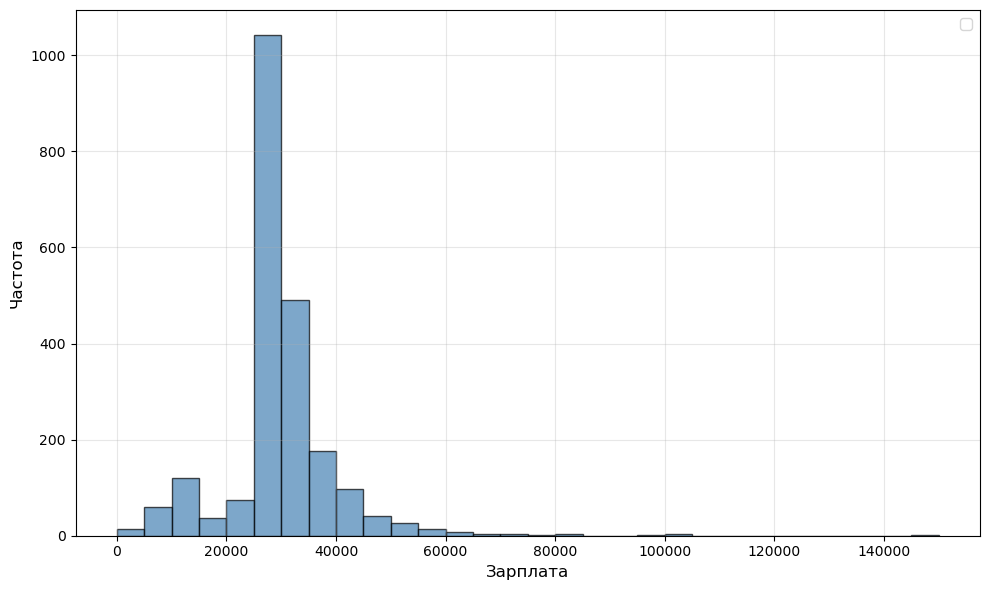

In [54]:
fig, axes = plt.subplots(figsize=(10, 6))

axes.hist(dff['salary'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes.set_xlabel('Зарплата', fontsize=12)
axes.set_ylabel('Частота', fontsize=12)
axes.legend(fontsize=11)
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Наибольшая частота наблюдается в интервале 25 000–30 000. Медиана и среднее расположены близко друг к другу, значит типичная зарплата находится в этом диапазоне. Присутствуют выбросы с единичными вакансиями с зарплатаой выше 60 000. Для школьников доступны вакансии преимущественно с зарплатой 27 000–30 000, что составляет основную массу предложений.

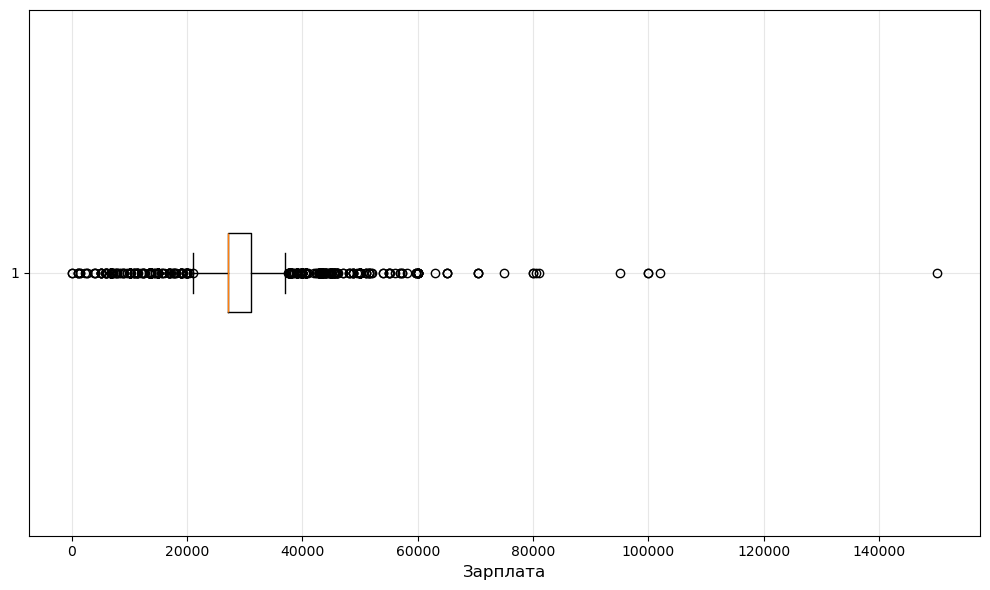

In [55]:
fig, axes = plt.subplots(figsize=(10, 6))

axes.boxplot(dff['salary'].dropna(), vert=False)
axes.set_xlabel('Зарплата', fontsize=12)
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

На графике видны множественные выбросы справа, значения более 60 тыс, включая экстремальные значения. Нулевые значения заменю на медиану. 
P.S ниже поняла откуда берутся огромные выбросы более 60 тыс рублей, это значения из вакансий предназанченных не только для школьников, но и для других групп соц защищенности.

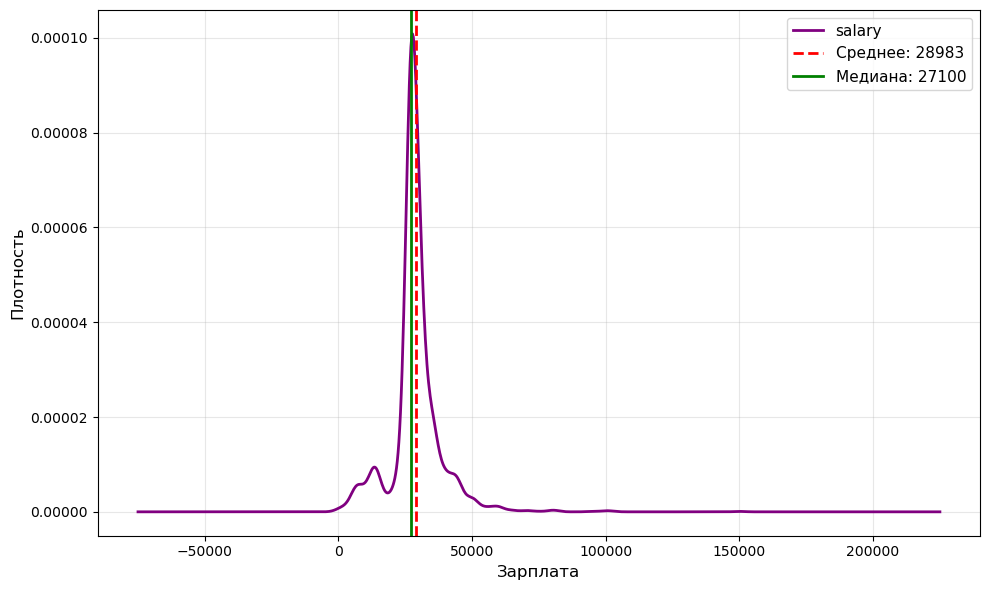

In [56]:
fig, axes = plt.subplots(figsize=(10, 6))

dff['salary'].dropna().plot.kde(ax=axes, linewidth=2, color='purple')
axes.axvline(dff['salary'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {dff["salary"].mean():.0f}')
axes.axvline(dff['salary'].median(), color='green', linestyle='-', linewidth=2, label=f'Медиана: {dff["salary"].median():.0f}')
axes.set_xlabel('Зарплата', fontsize=12)
axes.set_ylabel('Плотность', fontsize=12)
axes.legend(fontsize=11)
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Как и ранее видно, что рынок труда характеризуется высокой концентрацией предложений в узком диапазоне 25–30 тыс, с небольшим количеством высокооплачиваемых вакансий.

In [57]:
Q1 = dff['salary'].quantile(0.25)
Q3 = dff['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = dff[(dff['salary'] < lower_bound) | (dff['salary'] > upper_bound)]
print(f"\nВыбросы: {len(outliers)} ({len(outliers)/len(dff)*100:.1f}%)")
print(f"Границы: [{lower_bound:.0f}, {upper_bound:.0f}]")
print(f"Мин/Макс: {dff['salary'].min():.0f} / {dff['salary'].max():.0f}")


Выбросы: 481 (21.7%)
Границы: [20997, 37253]
Мин/Макс: 0 / 150000


481 выброс в распределении. Нижние выбросы актуальны для школьников. Верхние выбросы представляют собой высокооплачиваемые позиции, как и объяснила ранее. Для дальнейшего анализа я не буду удалять выбросы.

In [59]:
zeros = (dff['salary'] == 0).sum()
zeros

np.int64(2)

2 признак: geo, через latitude и longitude. Посмотрим распределение вакансий по стране.

In [60]:
!pip install geopandas

In [61]:
!pip install contextily

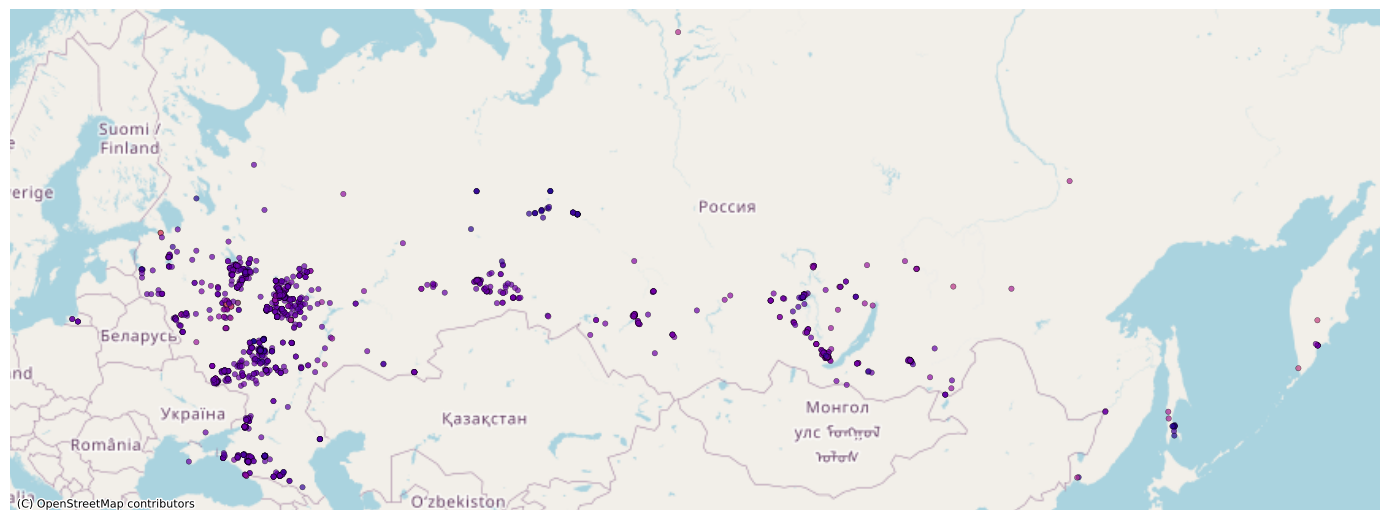

In [62]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(dff['longitude'], dff['latitude'])]
gdf = gpd.GeoDataFrame(dff, geometry=geometry, crs='EPSG:4326')
gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(14, 10))

gdf_web.plot(ax=ax, column='salary', cmap='plasma', 
             markersize=15, alpha=0.7, edgecolors='black', linewidth=0.3)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()

plt.tight_layout()
plt.show()

География показывает максимальную концентрация в европейской части, разреженную часть в Сибири и на Дальнем Востоке. Интересно, что на севере вакансий меньше всего. По всей стране распределение неравномерно.

Пометка: здесь код для графика строился с помощью ИИ и помощью интернета

In [63]:
dff['geo'].isna().sum()

np.int64(0)

Пропусков нет.

3 признак: educationRequirements - порядковая шкала. Определить доступность вакансий для школьников

In [64]:
edu_counts = dff['educationRequirements'].value_counts()
edu_counts

educationRequirements
NULL               1496
MIDDLE              626
MIDDLE_SPECIAL       83
UNFINISHED_HIGH       6
HIGH                  2
Name: count, dtype: int64

In [65]:
edu_order = ['NULL', 'MIDDLE', 'MIDDLE_SPECIAL', 'UNFINISHED_HIGH', 'HIGH']

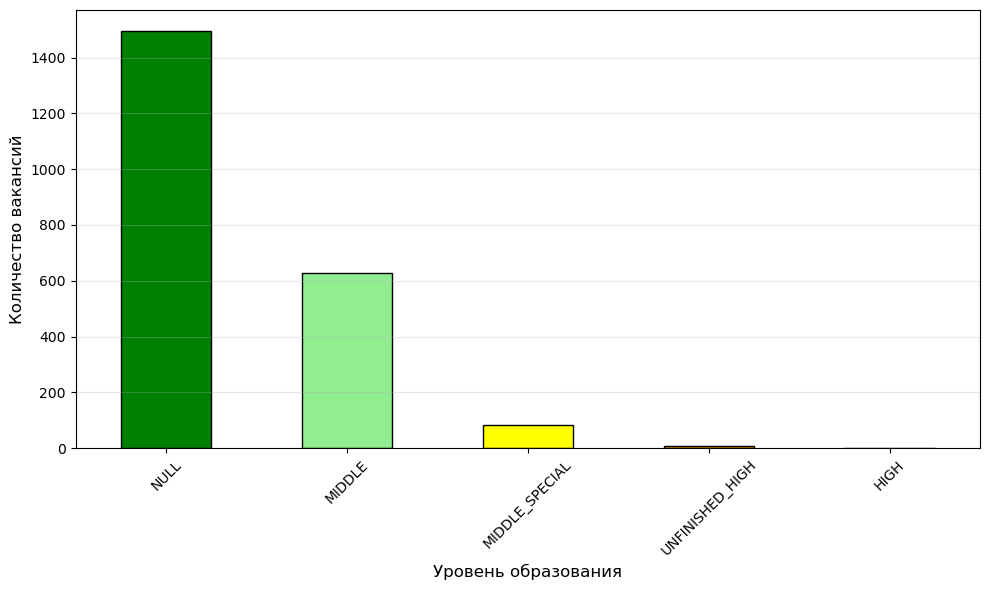

In [66]:
fig, ax = plt.subplots(figsize=(10, 6))

edu_ordered = pd.Series({level: edu_counts.get(level, 0) for level in edu_order})
edu_ordered.plot(kind='bar', ax=ax, color=['green', 'lightgreen', 'yellow', 'orange', 'red'], edgecolor='black')
ax.set_xlabel('Уровень образования', fontsize=12)
ax.set_ylabel('Количество вакансий', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

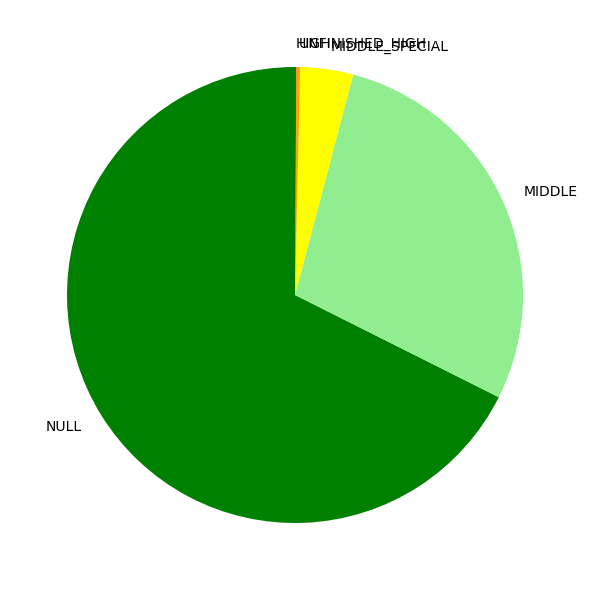

In [67]:
fig, ax = plt.subplots(figsize=(10, 6))

edu_counts.plot(kind='pie', ax=ax, startangle=90, 
                colors=['green', 'lightgreen', 'yellow', 'orange', 'red'])
ax.set_ylabel('')

plt.tight_layout()
plt.show()

90% вакансий не требуют специального образования и доступны для школьников, имеющих только общее среднее образование. Большинство вакансий не предъявляют образовательных требований. Каждая четвертая вакансия указывает школьное образование как достаточное
Высшее образование требуется лишь в 1% случаев, что скорее является ошибкой и противоречием в нашем случае.

In [68]:
dff['educationRequirements'].isna().sum()

np.int64(0)

Пропуски отсутствуют.

4 признак: busyType, определим доли форм занятости.

In [69]:
busy_counts = dff['busyType'].value_counts()
busy_counts

busyType
Полная занятость       1338
Временная               626
Частичная занятость     217
Сезонная                 15
Удалённая                14
Стажировка                3
Name: count, dtype: int64

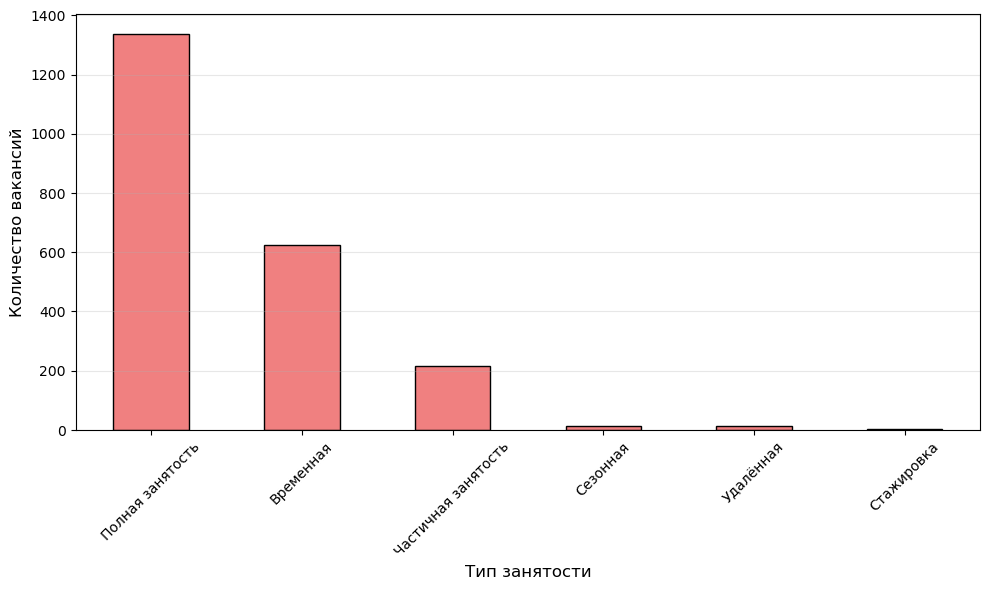

In [70]:
fig, ax = plt.subplots(figsize=(10, 6))

# Столбчатая диаграмма
busy_counts.plot(kind='bar', ax=ax, color='lightcoral', edgecolor='black')
ax.set_xlabel('Тип занятости', fontsize=12)
ax.set_ylabel('Количество вакансий', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Почему-то превалирует полная занятость, нужно изучать далее почему. Для школьников доступно около 40% вакансий с гибким графиком

In [71]:
dff['busyType'].isna().sum()

np.int64(0)

пропуски отсутсвтуют.

In [72]:
# Связь с зарплатой
dff.groupby('busyType')['salary'].mean().round().sort_values(ascending=False)

busyType
Стажировка             30000.0
Полная занятость       29962.0
Удалённая              28320.0
Временная              27811.0
Сезонная               27792.0
Частичная занятость    26437.0
Name: salary, dtype: Float64

Стажировки и полная занятость предлагают наивысшую оплату.
Частичная занятость имеет самую низкую среднюю зарплату — ожидаемо, так как предполагает меньше рабочих часов.

In [73]:
dff.groupby('busyType')['experienceRequirements'].apply(
    lambda x: (x == 0).mean() * 100
).round(1)

busyType
Временная               99.2
Полная занятость        96.9
Сезонная                93.3
Стажировка             100.0
Удалённая              100.0
Частичная занятость     98.2
Name: experienceRequirements, dtype: float64

Практически все типы занятости доступны соискателям без опыта. 

5 признак: regionName, определим регионы с наибольшим количеством вакансий для школьников

In [74]:
# Частотный анализ регионов
region_counts = dff['regionName'].value_counts()
region_counts

regionName
Нижегородская область    558
Иркутская область        337
Ярославская область      208
Тамбовская область       193
Белгородская область     133
                        ... 
Брянская область           1
Республика Коми            1
Республика Дагестан        1
Запорожская область        1
Удмуртская Республика      1
Name: count, Length: 63, dtype: int64

In [75]:
len(region_counts)

63

Всего в России 89 субъектов, поэтому 63 достаточно большая представленность, где есть вакансии подходящие для школьников.

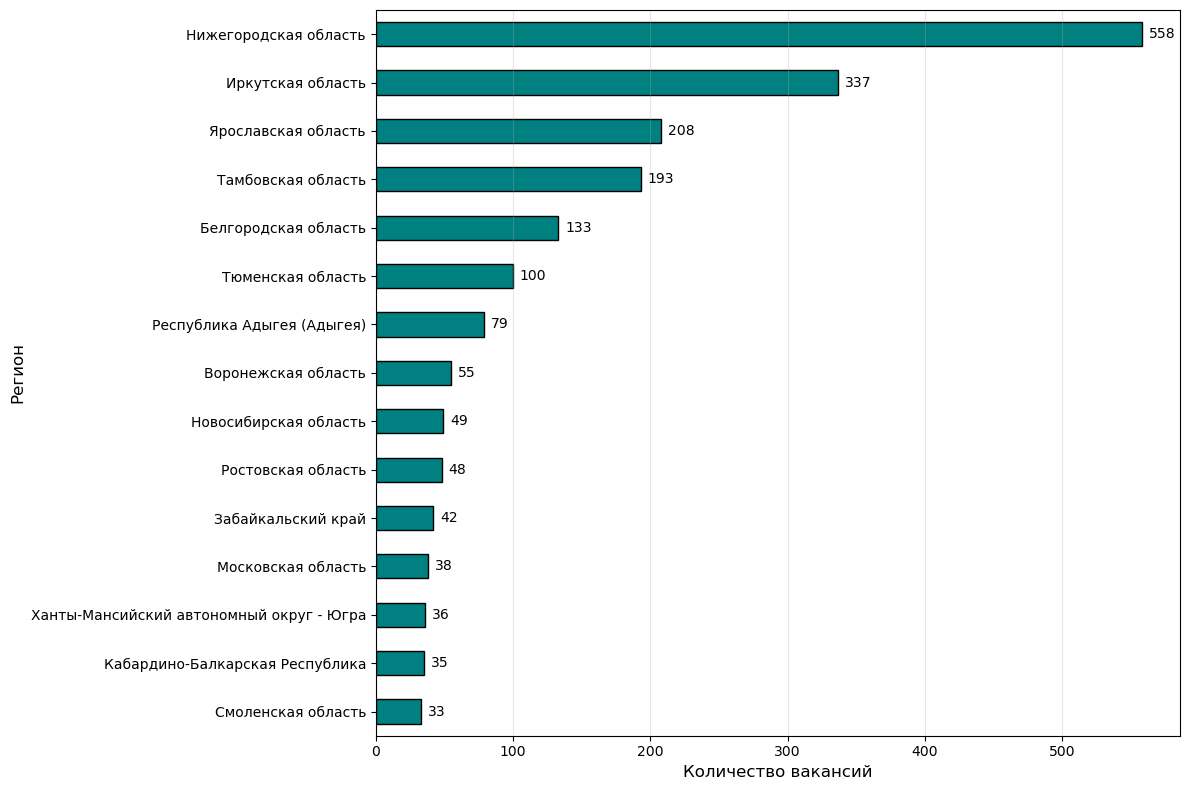

In [76]:
# посмотрим топ 15 
fig, ax = plt.subplots(figsize=(12, 8))

top15 = region_counts.head(15)
top15_sorted = top15.sort_values()
top15_sorted.plot(kind='barh', ax=ax, color='teal', edgecolor='black')
ax.set_xlabel('Количество вакансий', fontsize=12)
ax.set_ylabel('Регион', fontsize=12)

for i, v in enumerate(top15_sorted.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=10)

ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Представлены регионы из разных федеральных округов как промышленно развитые, так и аграрные.

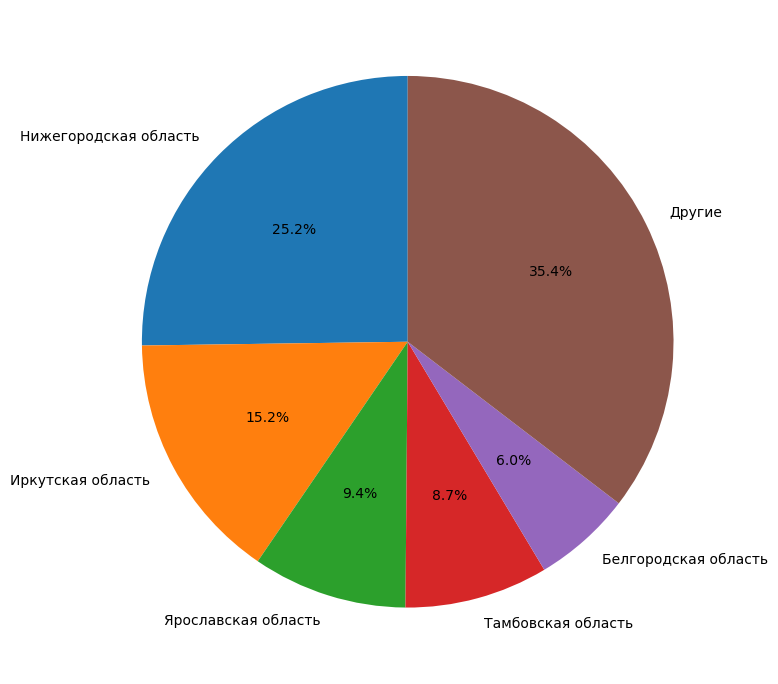

In [77]:
# распределение вакансий по регионам
fig, ax = plt.subplots(figsize=(8, 8))

top5 = region_counts.head(5)
others = pd.Series({'Другие': region_counts[5:].sum()})
pie_data = pd.concat([top5, others])

pie_data.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90)
ax.set_ylabel('')

plt.tight_layout()
plt.show()

35.4% вакансий приходится на все остальные регионы РФ (более 50 субъектов), не входящие в топ по количеству вакансий.

In [78]:
dff['regionName'].isna().sum()

np.int64(1)

1 пропуск оставляем

In [79]:
top5_regions = region_counts.head(5).index
for region in top5_regions:
    avg_salary = dff[dff['regionName'] == region]['salary'].mean()
    print(f"{region}: {avg_salary:.0f} руб.")

Нижегородская область: 29009 руб.
Иркутская область: 34840 руб.
Ярославская область: 29141 руб.
Тамбовская область: 19828 руб.
Белгородская область: 27320 руб.


Разрыв между самым высокооплачиваемым и низкооплачиваемым регионом составляет 15100.  Иркутская область предлагает самые высокие зарплаты, а Тамбовская — самые низкие, скорее всего связано с региональными экономическими особенностями.

# 3. Двумерный разведочный анализ данных (EDA) <a class="anchor" id="chapter2"></a>

Целевая переменная: salary — ключевой показатель привлекательности вакансии

Потенциальные предикторы: experienceRequirements, educationRequirements, busyType, regionName, vacancyName

Анализ 1: salary и experienceRequirements. Позволяет увидеть зависимость зарплаты от требуемого опыта.

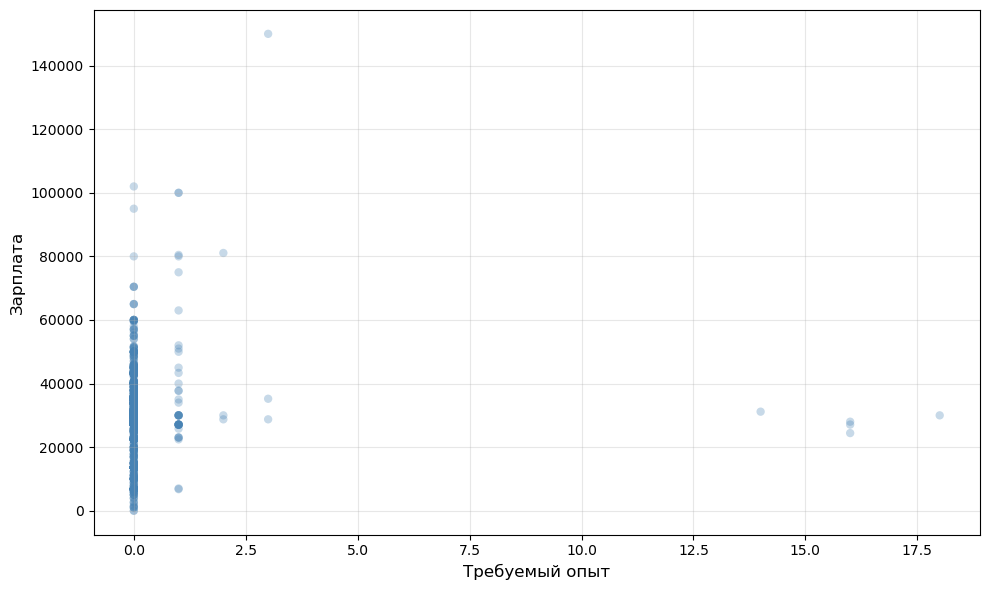

In [80]:
fig, ax = plt.subplots(figsize=(10, 6))

# Диаграмма рассеяния
ax.scatter(dff['experienceRequirements'], dff['salary'], 
           alpha=0.3, c='steelblue', edgecolors='none')
ax.set_xlabel('Требуемый опыт', fontsize=12)
ax.set_ylabel('Зарплата', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Связь слабая, увеличение опыта с 0 до 5 лет дает прирост зарплаты всего 5000 руб. Отсутствие опыта не является препятствием — 90% вакансий доступны без опыта, зарплата новичков незначительно ниже, чем у специалистов с опытом. 

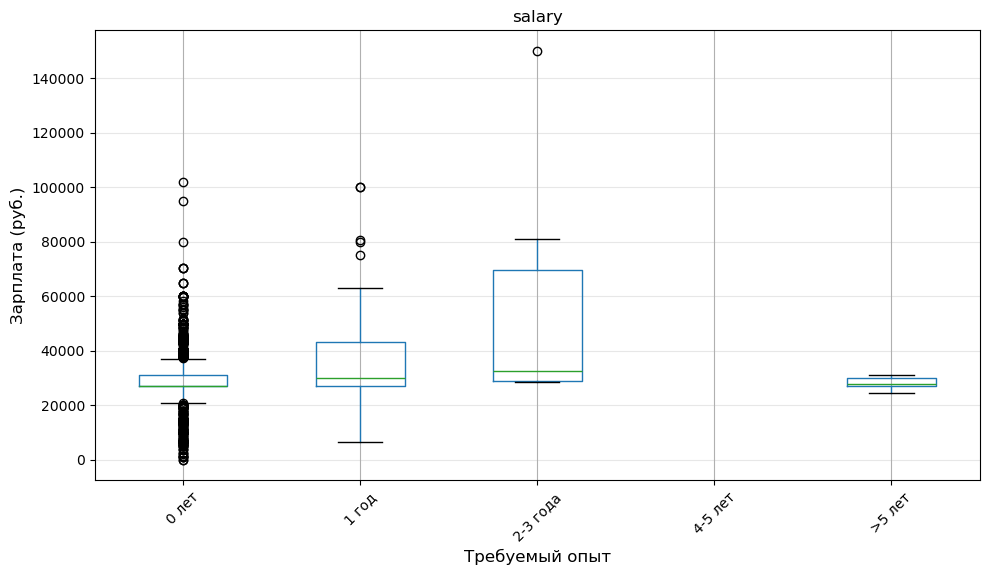

In [81]:
fig, ax = plt.subplots(figsize=(10, 6))

dff['exp_group'] = pd.cut(dff['experienceRequirements'], 
                          bins=[-1, 0, 1, 3, 5, 100],
                          labels=['0 лет', '1 год', '2-3 года', '4-5 лет', '>5 лет'])

dff.boxplot(column='salary', by='exp_group', ax=ax)
ax.set_xlabel('Требуемый опыт', fontsize=12)
ax.set_ylabel('Зарплата (руб.)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('') 
plt.tight_layout()
plt.show()

Провал в данных 4-5 лет.

Используем коэффициент корреляции Спирмена, тка как он устойчив к выбросам и не требует нормальности распределения

In [82]:
corr_data = dff[['salary', 'experienceRequirements']].dropna()
pearson_corr, pearson_p = pearsonr(corr_data['salary'], corr_data['experienceRequirements'])

spearman_corr, spearman_p = spearmanr(corr_data['salary'], corr_data['experienceRequirements'])
print(f"Пирсон: r = {pearson_corr:.3f}, p-value = {pearson_p:.4f}")
print(f"Спирмен: ρ = {spearman_corr:.3f}, p-value = {spearman_p:.4f}")

Пирсон: r = 0.047, p-value = 0.0278
Спирмен: ρ = 0.060, p-value = 0.0048


Связь положительная и очень слабая, но статистически значима. Увеличение опыта сопровождается крайне незначительным ростом зарплаты. Спирмен немного выше Пирсона, возможна нелинейность связи или влияние выбросов

Анализ 2: salary и educationRequirements. Сравним распределения зарплат для разных уровней образования

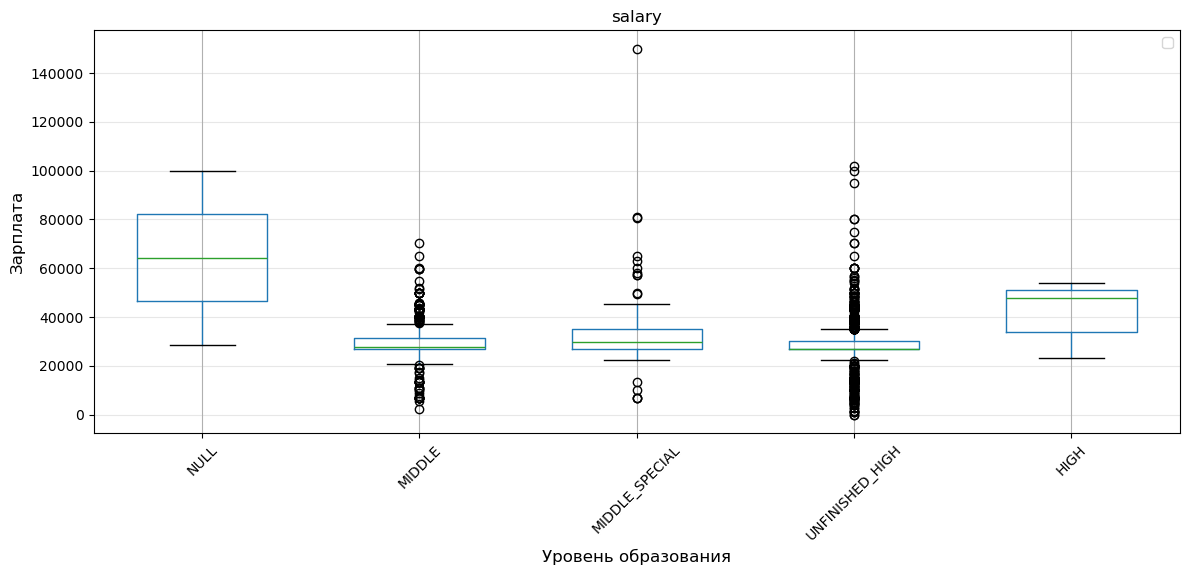

In [83]:
fig, ax = plt.subplots(figsize=(12, 6))

dff.boxplot(column='salary', by='educationRequirements', ax=ax, 
                    positions=range(len(edu_order)), widths=0.6)
ax.set_xlabel('Уровень образования', fontsize=12)
ax.set_ylabel('Зарплата', fontsize=12)
ax.set_xticklabels(edu_order, rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('')
plt.legend()
plt.tight_layout()
plt.show()

Выбираем ANOVA + парные сравнения. Нужно проверить, различаются ли средние зарплаты для разных уровней образовани.

In [84]:
from scipy.stats import f_oneway

edu_groups = []
edu_labels = []

for edu in edu_order:
    group_data = dff[dff['educationRequirements'] == edu]['salary'].dropna()
    if len(group_data) > 0:
        edu_groups.append(group_data.values)
        edu_labels.append(edu)

# ANOVA
if len(edu_groups) >= 2:
    f_stat, p_value = f_oneway(*edu_groups)
    print(f"F-статистика: {f_stat:.3f}")
    print(f"p-value: {p_value:.4f}")

F-статистика: 20.383
p-value: 0.0000


In [85]:
edu_means = dff.groupby('educationRequirements')['salary'].agg(['mean', 'median', 'count'])
print(edu_means.round())

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_se = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2))
    return (mean1 - mean2) / pooled_se

if 'NULL' in edu_labels and 'HIGH' in edu_labels:
    null_salary = dff[dff['educationRequirements'] == 'NULL']['salary'].dropna()
    high_salary = dff[dff['educationRequirements'] == 'HIGH']['salary'].dropna()
    
    if len(null_salary) > 0 and len(high_salary) > 0:
        d = cohens_d(high_salary, null_salary)
        print(f"{d:.2f}")

                          mean   median  count
educationRequirements                         
HIGH                   64375.0  64375.0      2
MIDDLE                 29956.0  27800.0    626
MIDDLE_SPECIAL         34322.0  30000.0     83
NULL                   28178.0  27093.0   1496
UNFINISHED_HIGH        42349.0  48000.0      6
3.78


Существуют статистически значимые различия в зарплатах между уровнями образования, логично. Эффект парного сравнения сильный.

Для 99% выборки уровень образования практически не влияет на зарплату — разница между NULL и MIDDLE составляет всего 1800. Высокие зарплаты в группах HIGH и UNFINISHED_HIGH представляют собой единичные случаи, не характерные для рынка труда школьников, это выбросы, которые далее мы будем винзоризовать.

Анализ 3: salary и busyType, нужно сравнить зарплаты для разных типов занятости

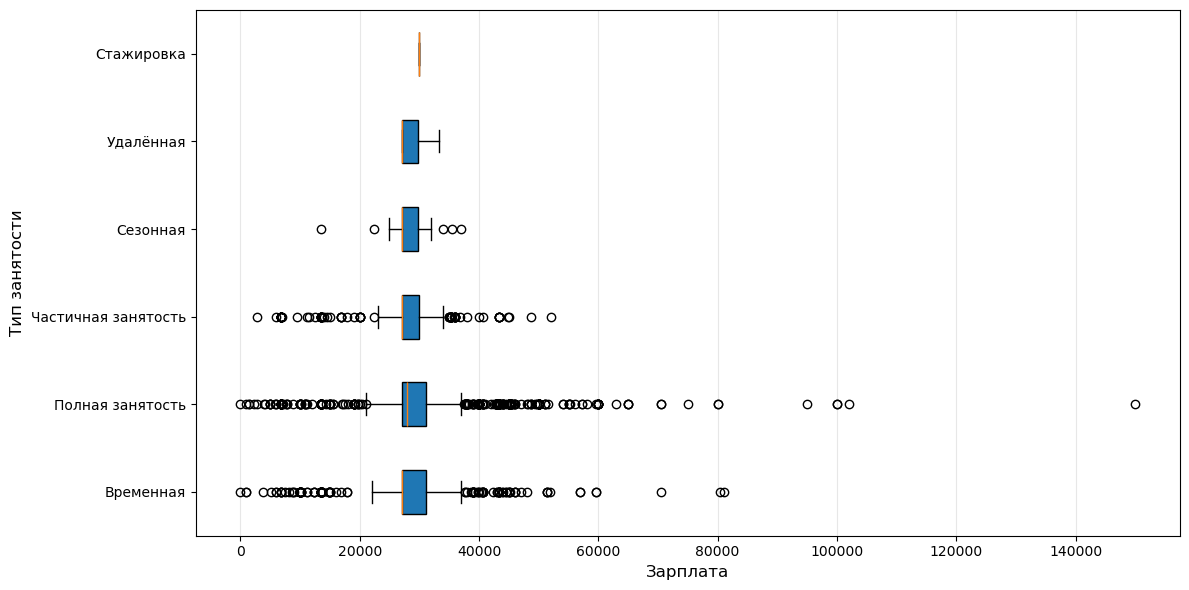

In [86]:
fig, ax = plt.subplots(figsize=(12, 6))

busy_types = dff['busyType'].unique()
data_to_plot = [dff[dff['busyType'] == bt]['salary'].dropna() for bt in busy_types]

bp = ax.boxplot(data_to_plot, vert=False, labels=busy_types, patch_artist=True)
ax.set_xlabel('Зарплата', fontsize=12)
ax.set_ylabel('Тип занятости', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')


plt.tight_layout()
plt.show()


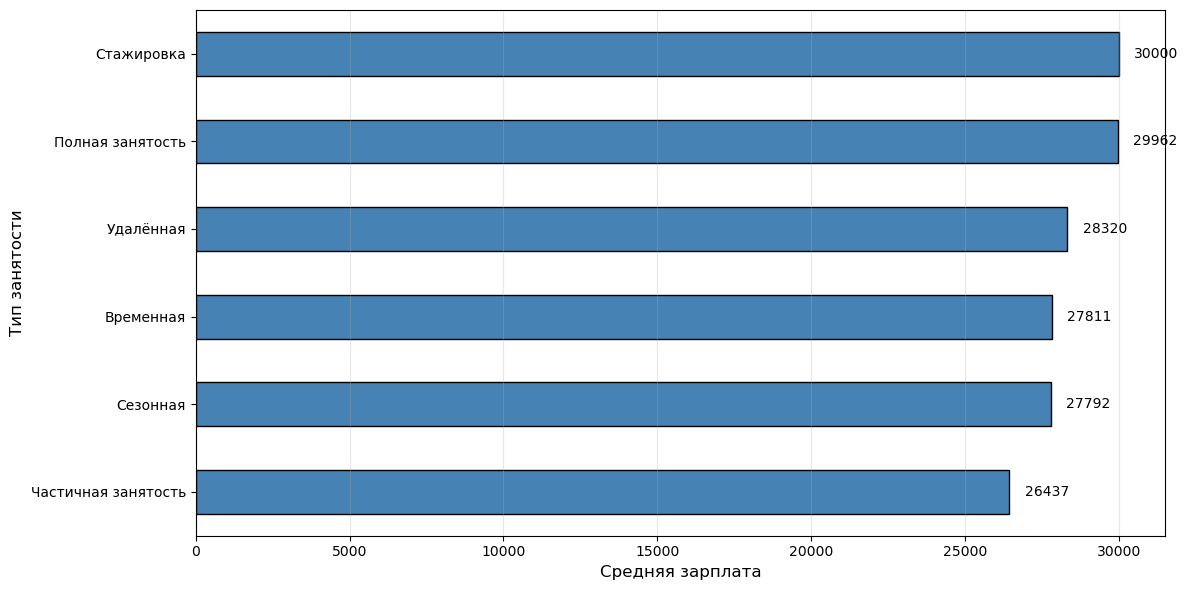

In [87]:
fig, ax = plt.subplots(figsize=(12, 6))


mean_salary = dff.groupby('busyType')['salary'].mean().sort_values()
mean_salary.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Средняя зарплата', fontsize=12)
ax.set_ylabel('Тип занятости', fontsize=12)

for i, v in enumerate(mean_salary.values):
    ax.text(v + 500, i, f'{v:.0f}', va='center', fontsize=10)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Дисперсия зарплат максимальна в полной занятости и минимальна в стажировках и частичной занятости. Наиболее выгодными по оплате являются стажировки и полная занятость. Разница в оплате между типами занятости пропорциональна затрачиваемому времени.

ANOVA для категориального признака. Нужно проверить, влияет ли тип занятости на уровень зарплаты

In [88]:
busy_groups = []
busy_labels = []

for bt in busy_types:
    group = dff[dff['busyType'] == bt]['salary'].dropna()
    if len(group) > 5:  
        busy_groups.append(group.values)
        busy_labels.append(bt)

# ANOVA
if len(busy_groups) >= 2:
    f_stat, p_value = f_oneway(*busy_groups)
    print(f"F-статистика: {f_stat:.3f}")
    print(f"p-value: {p_value:.4f}")

busy_stats = dff.groupby('busyType')['salary'].agg(['count', 'mean', 'median', 'std']).round()
print(busy_stats.sort_values('mean', ascending=False))

F-статистика: 9.517
p-value: 0.0000
                     count     mean   median      std
busyType                                             
Стажировка               3  30000.0  30000.0      0.0
Полная занятость      1338  29962.0  28000.0  10247.0
Удалённая               14  28320.0  27093.0   1927.0
Временная              626  27811.0  27093.0   8870.0
Сезонная                15  27792.0  27093.0   5631.0
Частичная занятость    217  26437.0  27093.0   8902.0


Вывод: тип занятости значимо логично влияет на зарплату

4 анализ: salary и regionName. Слишком много регионов для boxplot, покажем только топ-10 регионов.

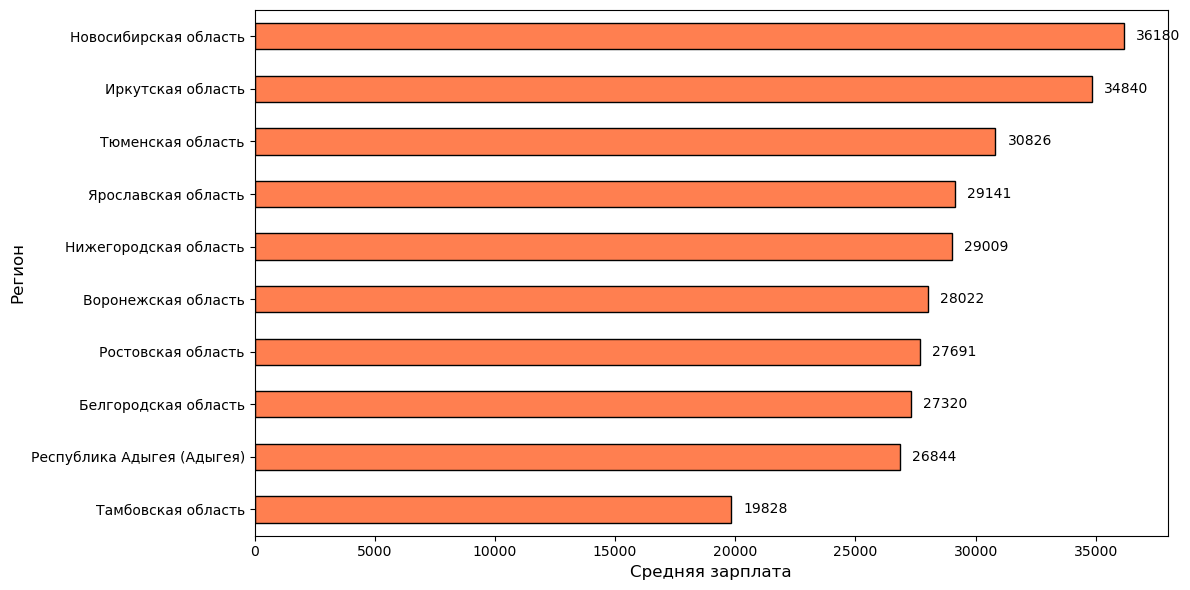

In [89]:
top10_regions = dff['regionName'].value_counts().head(10).index

region_salary = dff[dff['regionName'].isin(top10_regions)].groupby('regionName')['salary'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

region_salary['mean'].sort_values().plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Средняя зарплата', fontsize=12)
ax.set_ylabel('Регион', fontsize=12)

for i, v in enumerate(region_salary['mean'].sort_values().values):
    ax.text(v + 500, i, f'{v:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Коэффициент вариации. Обоснование: Оценка межрегиональных различий в оплате труда.

In [90]:
region_means = dff.groupby('regionName')['salary'].mean()
cv_regions = region_means.std() / region_means.mean() * 100

print(f"Средняя зарплата по регионам: {region_means.mean():.0f} руб.")
print(f"Стандартное отклонение между регионами: {region_means.std():.0f} руб.")
print(f"Коэффициент вариации между регионами: {cv_regions:.1f}%")

print(f"\nРегион с максимальной зарплатой: {region_means.idxmax()} ({region_means.max():.0f} руб.)")
print(f"Регион с минимальной зарплатой: {region_means.idxmin()} ({region_means.min():.0f} руб.)")
print(f"Размах: {region_means.max() - region_means.min():.0f} руб.")

Средняя зарплата по регионам: 31358 руб.
Стандартное отклонение между регионами: 12133 руб.
Коэффициент вариации между регионами: 38.7%

Регион с максимальной зарплатой: Город Санкт-Петербург (88500 руб.)
Регион с минимальной зарплатой: Республика Карелия (5118 руб.)
Размах: 83382 руб.


Новосибирская и Иркутская области опережают средние показатели (вероятно, из-за северных надбавок). Тамбовская область — почти вдвое ниже лидеров. Санкт-Петербург и Карелия требуют проверки — возможно, единичные вакансии искажают статистику.

5 анализ: salary и vacancyName. Выявим наиболее высокооплачиваемые профессии для школьников.

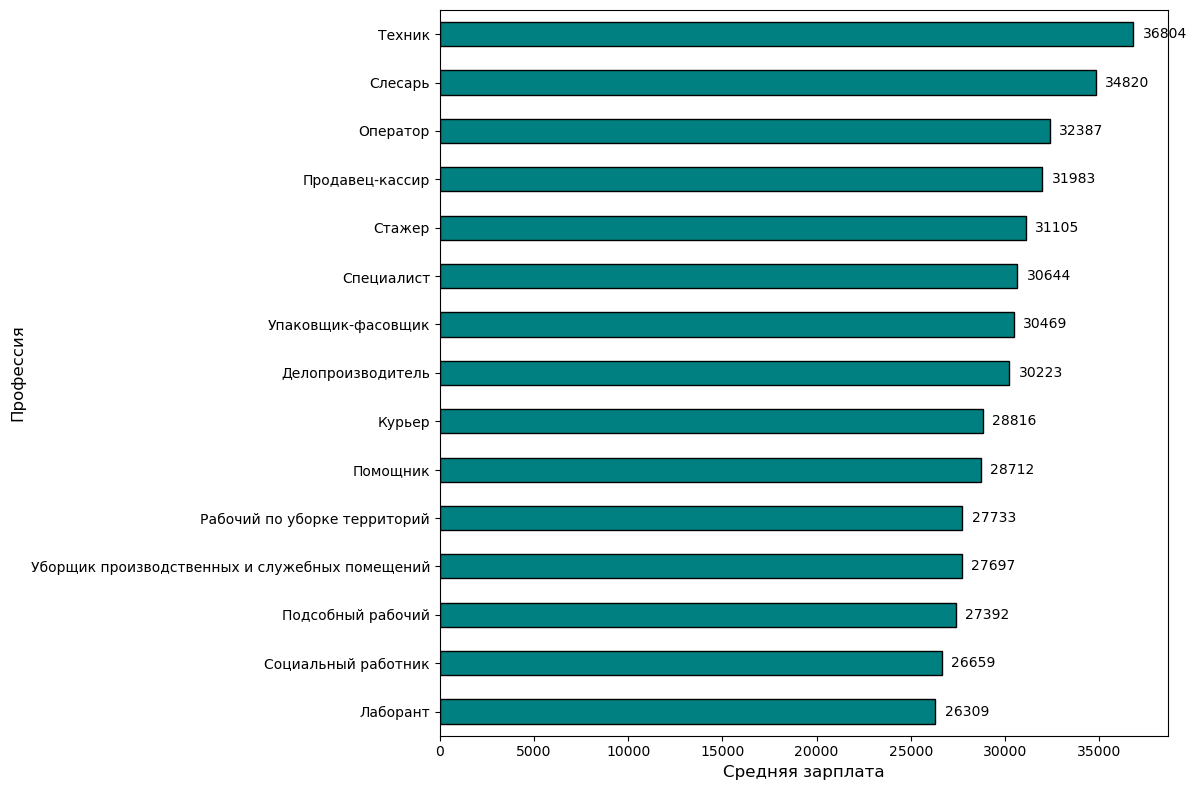

In [91]:
top15_prof = dff['vacancyName'].value_counts().head(15).index

prof_salary = dff[dff['vacancyName'].isin(top15_prof)].groupby('vacancyName')['salary'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

prof_salary['mean'].sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='black')
ax.set_xlabel('Средняя зарплата', fontsize=12)
ax.set_ylabel('Профессия', fontsize=12)

for i, v in enumerate(prof_salary['mean'].sort_values().values):
    ax.text(v + 500, i, f'{v:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

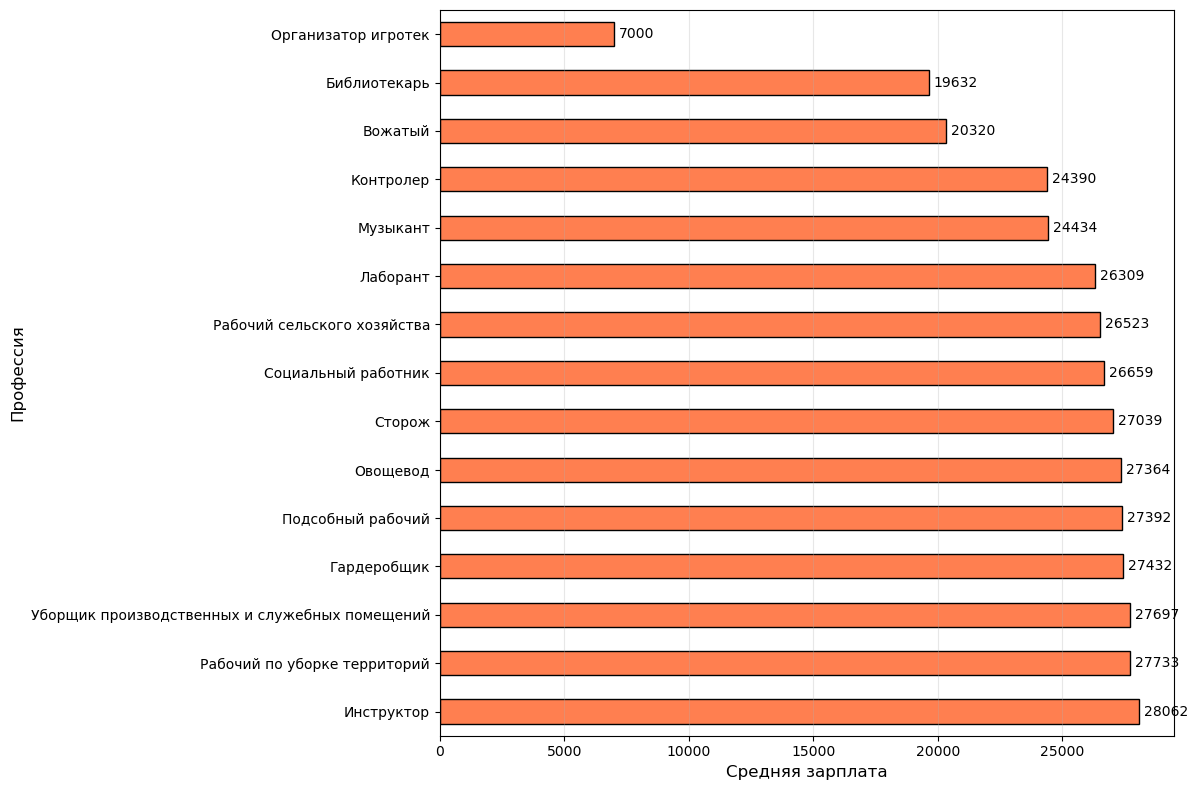

In [92]:
prof_counts = dff['vacancyName'].value_counts()
popular_profs = prof_counts[prof_counts >= 3].index

prof_salary_low = dff[dff['vacancyName'].isin(popular_profs)].groupby('vacancyName')['salary'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=True)

lowest_15 = prof_salary_low.head(15)

fig, ax = plt.subplots(figsize=(12, 8))

lowest_15['mean'].sort_values(ascending=False).plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Средняя зарплата', fontsize=12)
ax.set_ylabel('Профессия', fontsize=12)

for i, v in enumerate(lowest_15['mean'].sort_values(ascending=False).values):
    ax.text(v + 200, i, f'{v:.0f}', va='center', fontsize=10)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [93]:
prof_cv = dff.groupby('vacancyName')['salary'].agg(['mean', 'std', 'count'])
prof_cv['cv'] = (prof_cv['std'] / prof_cv['mean'] * 100).round(1)

high_cv = prof_cv[prof_cv['count'] >= 5].sort_values('cv', ascending=False).head(10)
print(high_cv[['mean', 'std', 'cv', 'count']].round())

                         mean      std    cv  count
vacancyName                                        
Менеджер по продажам  43634.0  30422.0  70.0     10
Промоутер-аниматор    34057.0  21101.0  62.0     10
Администратор         44575.0  25605.0  57.0     10
Библиотекарь          19632.0  10574.0  54.0      7
Официант              34198.0  17747.0  52.0     17
Слесарь               34820.0  16564.0  48.0     70
Лаборант              26309.0   9916.0  38.0     27
Курьер                28816.0  10062.0  35.0     58
Специалист            30644.0  10672.0  35.0     42
Подсобный рабочий     27392.0   9280.0  34.0    594


Наиболее стабильный заработок обеспечивают массовые рабочие профессии.Потенциально более высокий доход могут дать профессии с совокупной оплатой (менеджер по продажам, промоутер), у них же наибольший разброс зарплат.

Анализ 6: Дополнительно имеет смысл посмотреть на количество рабочих мест, которые предоставляют вакансии, чтобы выявить популярные.

In [94]:
workplace_stats = dff.groupby('vacancyName')['workPlaces'].agg(['mean', 'median', 'min', 'max', 'count', 'sum']).sort_values('mean', ascending=False)

workplace_stats.sort_values('mean', ascending=False).head(10).round(1)

,mean,median,min,max,count,sum
vacancyName,,,,,,
Обработчик рыбы и морепродуктов,15.0,15.0,15,15,1,15
Спортсмен,13.7,5.0,1,35,3,41
Гардеробщик,8.8,3.0,1,36,12,106
Транспортировщик,7.8,4.5,2,20,4,31
Медицинский работник,6.5,6.5,1,12,2,13
Подсобный рабочий,6.2,2.0,1,300,594,3710
Организатор игротек,4.7,4.0,4,6,3,14
Стажер,4.4,2.0,1,43,32,142
Менеджер,4.4,2.0,1,14,7,31


Наибольшее количество рабочих мест представляет вакансии рабочих по уборке.

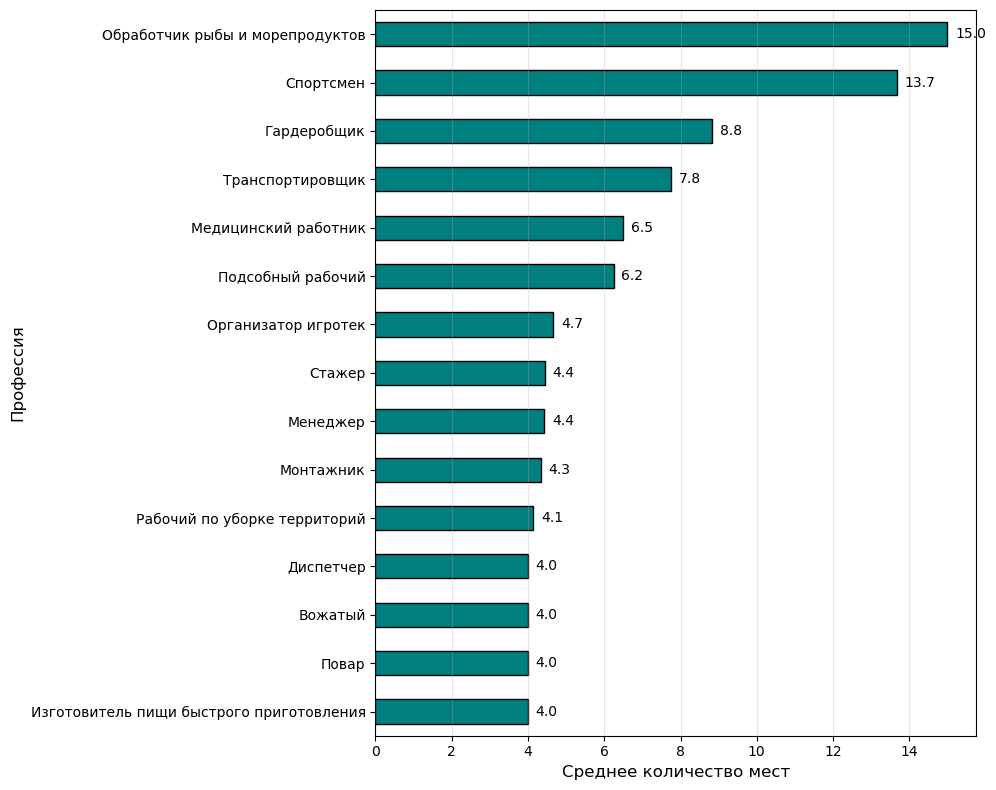

In [95]:
fig, ax = plt.subplots(figsize=(10, 8))

workplace_stats.head(15)['mean'].sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='black')
ax.set_xlabel('Среднее количество мест', fontsize=12)
ax.set_ylabel('Профессия', fontsize=12)

for i, v in enumerate(workplace_stats.head(15)['mean'].sort_values().values):
    ax.text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=10)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Обработчика рыбы и морепродуктов не считаем, так как это одна единственная вакансия с 15 рабочими местами. При этом по среднему количеству мест лидируют вакансии спортсменов и гаредеробщиков.

Анализ 7: размер компании и зарплата для школьников

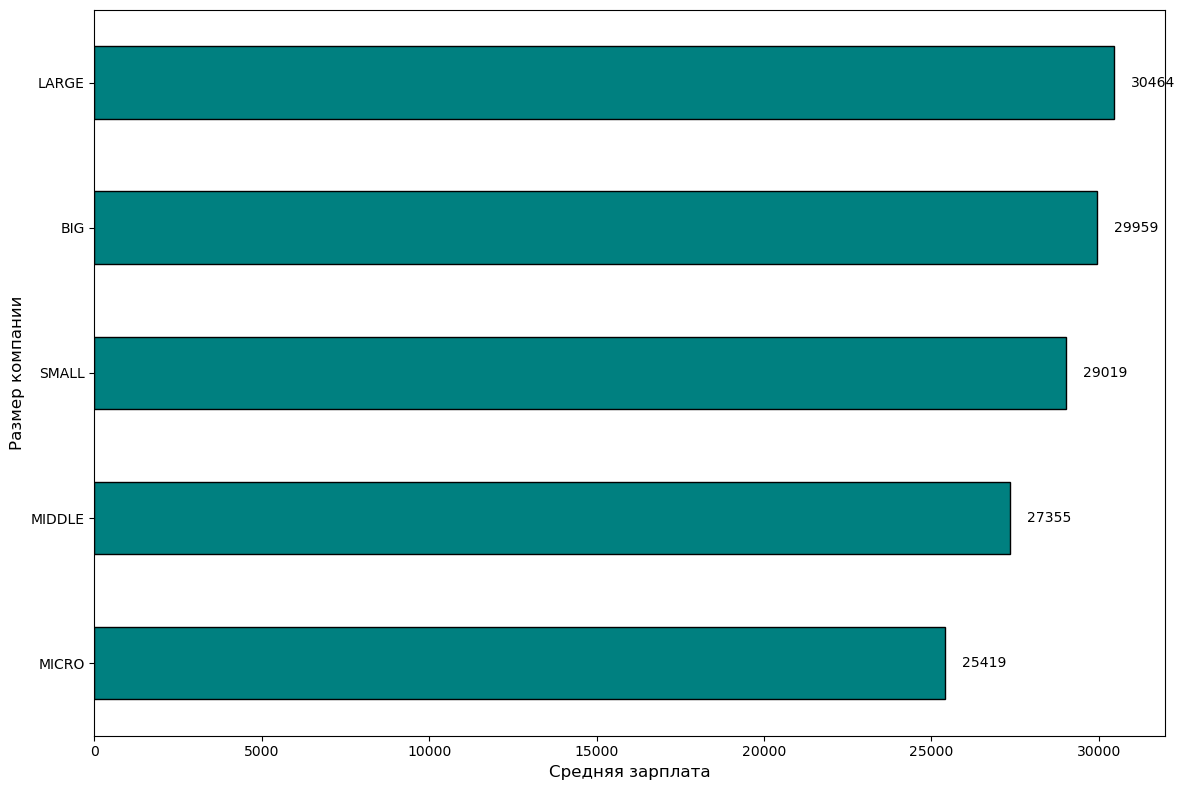

In [96]:
salary_size = dff['companyBusinessSize'].value_counts().index

prof_salary = dff[dff['companyBusinessSize'].isin(salary_size)].groupby('companyBusinessSize')['salary'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

prof_salary['mean'].sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='black')
ax.set_xlabel('Средняя зарплата', fontsize=12)
ax.set_ylabel('Размер компании', fontsize=12)

for i, v in enumerate(prof_salary['mean'].sort_values().values):
    ax.text(v + 500, i, f'{v:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Вполне логичная раазница, разница в микро и в гигантских компаниях около 5 тыс рублей.

Анализ 8: распределение количества вакансий для разных размеров компаний

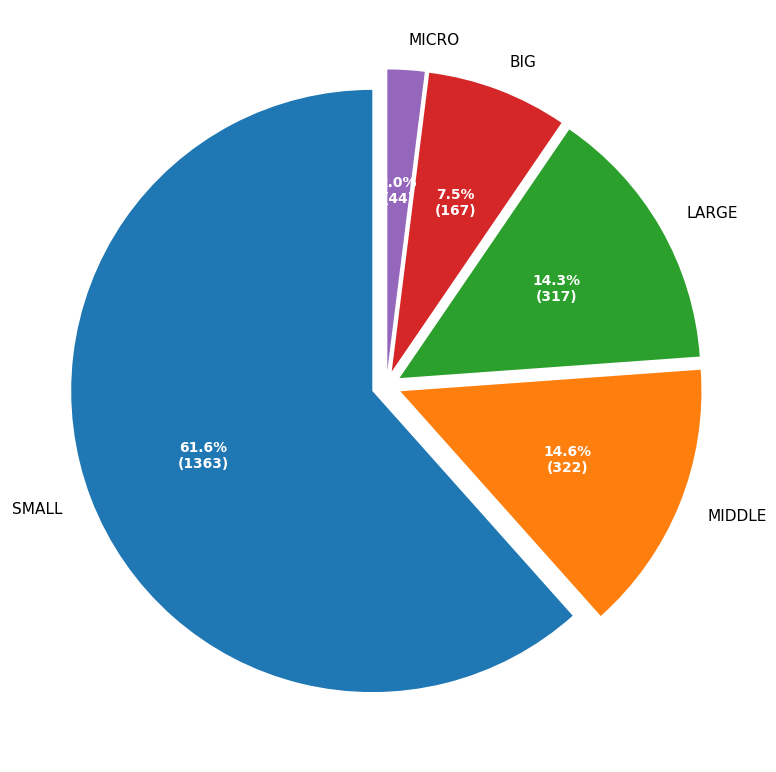

In [97]:
fig, ax = plt.subplots(figsize=(8, 8))

size_counts = dff['companyBusinessSize'].value_counts()

def autopct_format(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({val})'
    return my_autopct

wedges, texts, autotexts = ax.pie(
    size_counts.values, 
    labels=size_counts.index,
    autopct=autopct_format(size_counts.values),
    startangle=90,
    explode=[0.05] * len(size_counts)
)

for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

Анализ 9: Зарплата и географические признаки

Рассчитаем коэффициенты корреляции зарплаты и географичиескими признаками, широты и долготы. Чтобы выявить зависимости между зарплатой и местоположением вакансий.

In [98]:
stats.spearmanr(dff[['salary','latitude']].dropna())

SignificanceResult(statistic=np.float64(0.16282384975720715), pvalue=np.float64(1.4194955019611233e-14))

Наблюдается статистически значимая положительная, но очень слабая связь между широтой и зарплатой. В более северных регионах зарплаты незначительно выше, что объясняется северными надбавками. 

In [99]:
stats.spearmanr(dff[['salary','longitude']].dropna())

SignificanceResult(statistic=np.float64(0.2936784247272058), pvalue=np.float64(3.923717299045154e-45))

Наблюдается более сильная связь между долготой и зарплатой, чем с широтой. При движении с запада на восток зарплата имеет тенденцию к росту, в связи с регаональными надбавками.

In [100]:
dff[['salary',
    'latitude',
    'longitude']].corr('spearman') 
# матрица коэффициентов корреляции Спирмена

,salary,latitude,longitude
salary,1.000000,0.162824,0.293678
latitude,0.162824,1.000000,0.025205
longitude,0.293678,0.025205,1.000000


Наблюдается более сильная связь между долготой и зарплатой, чем с широтой. При движении с запада на восток зарплата имеет тенденцию к росту, в связи с регаональными надбавками.

# 4. Предобработка данных <a class="anchor" id="chapter3"></a>

Что уже сделано в ходе EDA:

Столбец salary очищен от текстовых префиксов и преобразован в числовой формат

Столбец workPlaces преобразован в числовой формат

Столбец experienceRequirements приведен к числовому формату с заменой пропусков на 0, преобразован в тип данных category с выделением групп

Столбец premium распарсен в отдельные признаки: premium_size, premium_type, bonus_type

Столбец educationRequirements преобразован в стандартизированные значения: NULL, MIDDLE, MIDDLE_SPECIAL, UNFINISHED_HIGH, HIGH. C выделением специальности в отдельный признак

Столбец geo распарсен на отдельные признаки latitude и longitude

Столбец vacancyName объеденен в общие категории и объединены дублирующиеся названия профессий

Что нужно сделать: 

1. Заполнить пропуски в salary медианным значением 27 100, их мало, но все равно, чтобы не смещать распределение заменю
2. Для выбросов зарплаты значения, применить винзоризацию 99 перцентиля
3. Выброс с опытом значения более 5 лет - единичные случаи, оставить как есть. 
4. Машстабировать premium_size
5. Подготовить данные к кластеризации

In [101]:
zero_count = (dff['salary'] == 0).sum()
zero_count

np.int64(2)

In [102]:
median_salary = dff['salary'].median()
dff.loc[dff['salary'] == 0, 'salary'] = median_salary

In [103]:
(dff['salary'] == 0).sum()

np.int64(0)

Заполнили два пропуска

Применяем винзоризацию

In [104]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

p99 = dff['salary'].quantile(0.99)
dff['salary_cluster'] = dff['salary'].clip(upper=p99)

scaler_salary = RobustScaler()
scaler_exp = RobustScaler()

dff['salary_scaled'] = scaler_salary.fit_transform(dff[['salary_cluster']])
dff['exp_scaled'] = scaler_exp.fit_transform(dff[['experienceRequirements']])

Рассмотрим как меняются гистограммы распределения значения признака salary после применения к ним различных приемов масштабирования значений.

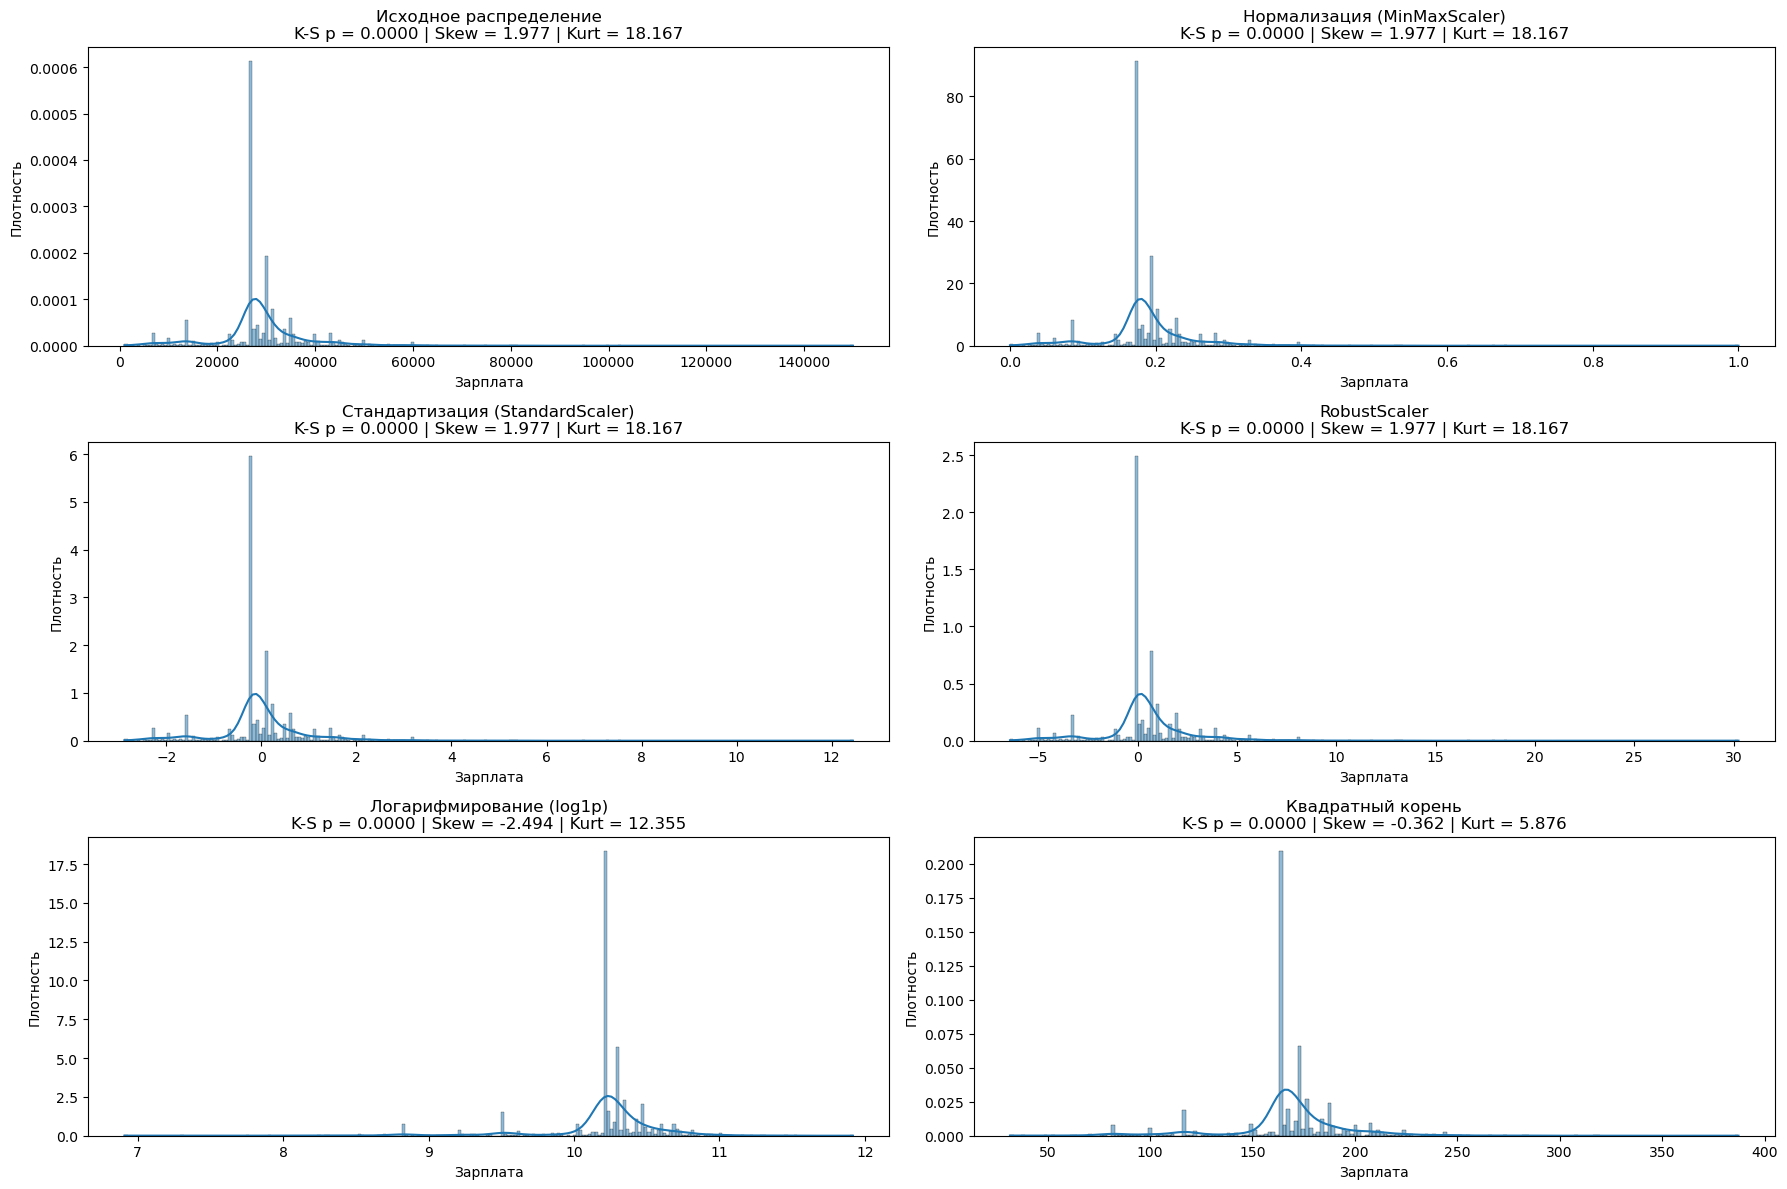

In [105]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from scipy.stats import kstest  
from scipy.stats import skew, kurtosis

salary_array = dff['salary'].dropna().values.astype(float)  # сначала в float
salary = salary_array.reshape(-1, 1)  # затем в 2D

salary_minmax = MinMaxScaler().fit_transform(salary)
salary_standard = StandardScaler().fit_transform(salary)
salary_robust = RobustScaler().fit_transform(salary)

if np.any(salary < 0):
    print("Внимание: есть отрицательные значения! Лог и корень не применяются.")
    salary_log = None
    salary_sqrt = None
else:
    salary_log = np.log1p(salary.flatten()).reshape(-1, 1)
    salary_sqrt = np.sqrt(salary.flatten()).reshape(-1, 1)


plots = [
    (salary, "Исходное распределение"),
    (salary_minmax, "Нормализация (MinMaxScaler)"),
    (salary_standard, "Стандартизация (StandardScaler)"),
    (salary_robust, "RobustScaler"),
]

if salary_log is not None:
    plots.append((salary_log, "Логарифмирование (log1p)"))
    plots.append((salary_sqrt, "Квадратный корень"))

plt.figure(figsize=(18, 12))

for i, (data, title) in enumerate(plots):
    data_flat = data.flatten()
    
    mu = np.mean(data_flat)
    sigma = np.std(data_flat)

    ks_stat, p_value = kstest(data_flat, 'norm', args=(mu, sigma))
   
    skewness = skew(data_flat)
    kurt = kurtosis(data_flat)
    
    plt.subplot(3, 2, i + 1)
    sns.histplot(data_flat, kde=True, stat="density")
    
    plt.title(
        f"{title}\n"
        f"K-S p = {p_value:.4f} | "
        f"Skew = {skewness:.3f} | "
        f"Kurt = {kurt:.3f}"
    )
    
    plt.xlabel("Зарплата")
    plt.ylabel("Плотность")

plt.tight_layout()
plt.show()

Мы видим сильную правостороннюю асимметрию, островершинное распределение, данные распределны ненормально.
Ни одна из трансформаций не привела к нормальному распределению зарплаты. Посмотрим что после винзоризации 99%


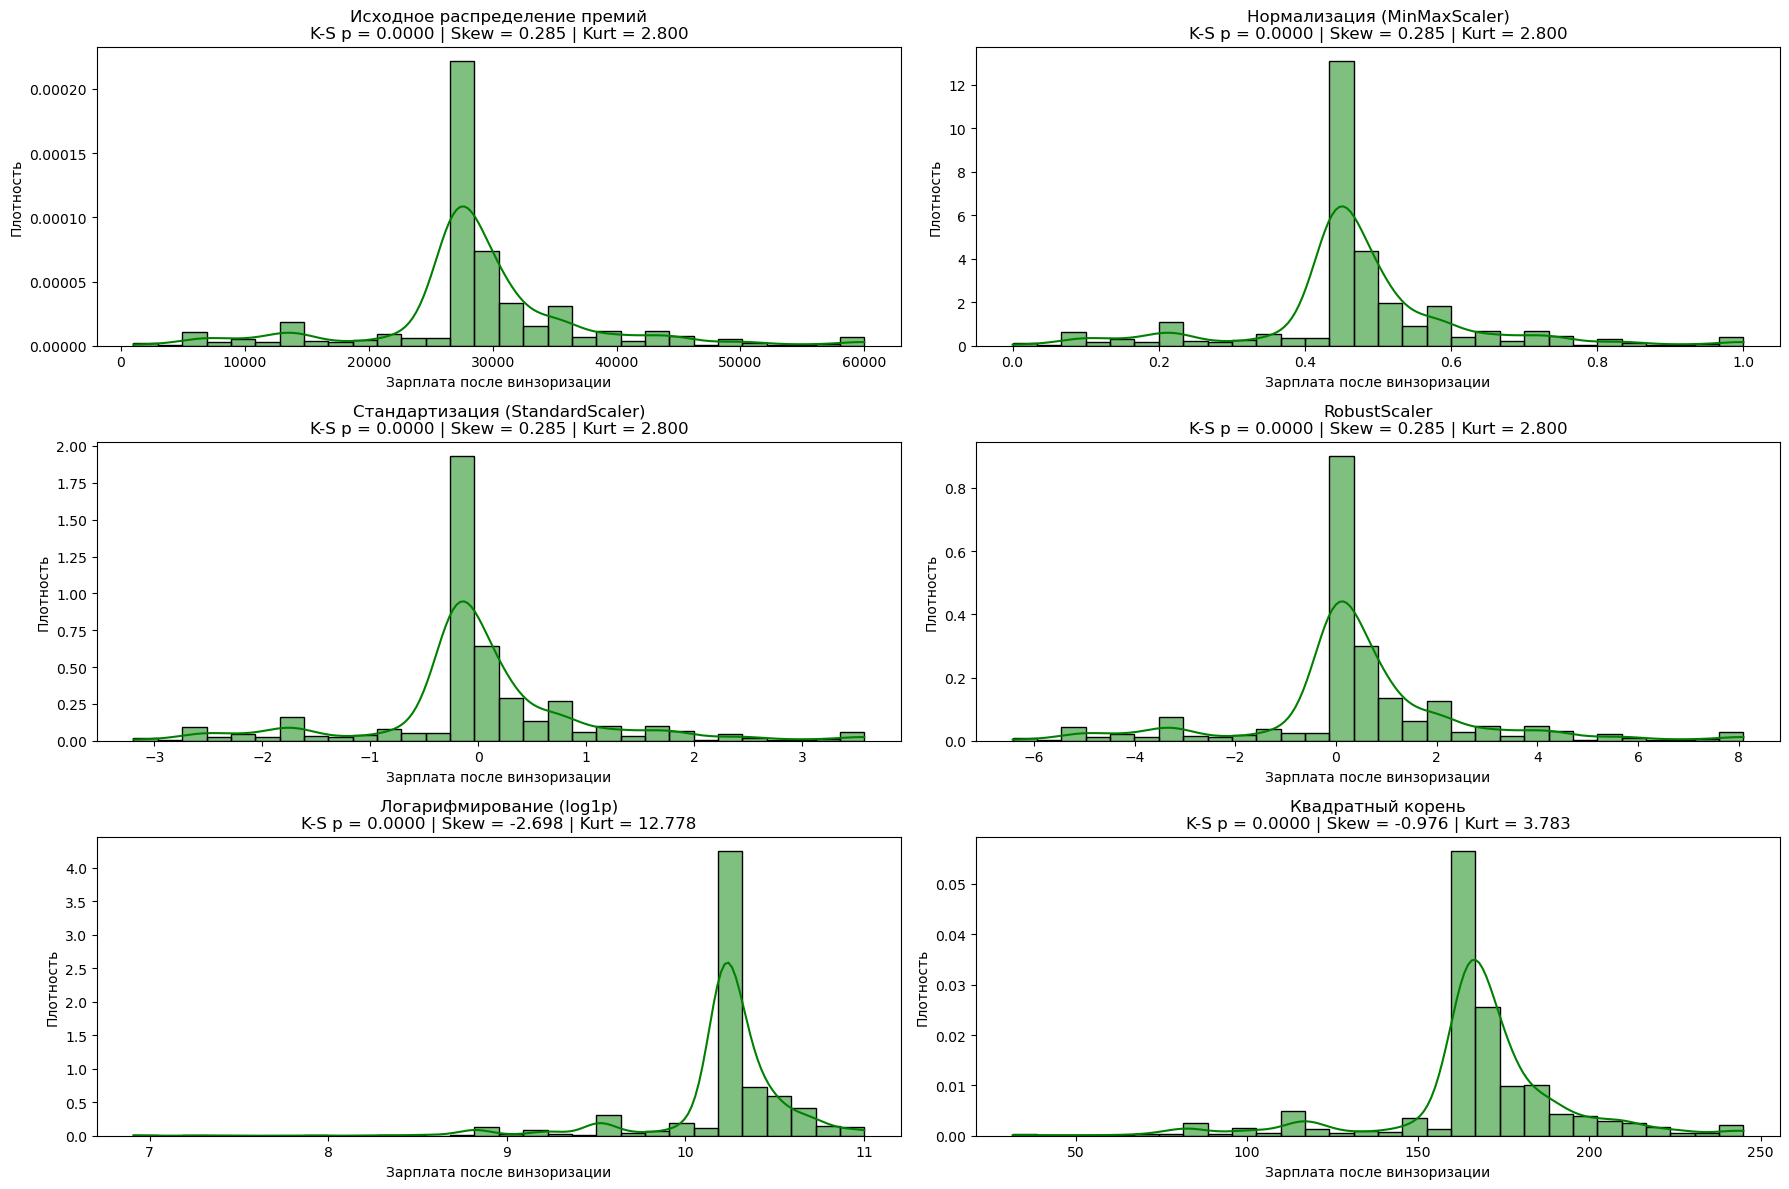

In [106]:
premium_data = dff['salary_cluster'].dropna().values.astype(float).reshape(-1, 1)

if len(premium_data) == 0:
    print("Нет данных по зарплатам для анализа")
else:
    premium_minmax = MinMaxScaler().fit_transform(premium_data)
    premium_standard = StandardScaler().fit_transform(premium_data)
    premium_robust = RobustScaler().fit_transform(premium_data)
    
    if np.any(premium_data < 0):
        print("Внимание: есть отрицательные значения — log и sqrt не применяются")
        premium_log = None
        premium_sqrt = None
    else:
        premium_log = np.log1p(premium_data)
        premium_sqrt = np.sqrt(premium_data)

    plots = [
        (premium_data, "Исходное распределение премий"),
        (premium_minmax, "Нормализация (MinMaxScaler)"),
        (premium_standard, "Стандартизация (StandardScaler)"),
        (premium_robust, "RobustScaler"),
    ]
    
    if premium_log is not None:
        plots.append((premium_log, "Логарифмирование (log1p)"))
        plots.append((premium_sqrt, "Квадратный корень"))
    
    plt.figure(figsize=(18, 12))
    
    for i, (data, title) in enumerate(plots):
        data_flat = data.flatten()
        
        mu = np.mean(data_flat)
        sigma = np.std(data_flat)
        
        ks_stat, p_value = kstest(data_flat, 'norm', args=(mu, sigma))
        
        skewness = skew(data_flat)
        kurt = kurtosis(data_flat)
        
        plt.subplot(3, 2, i + 1)
        sns.histplot(data_flat, kde=True, stat="density", color="green", bins=30)
        
        plt.title(
            f"{title}\n"
            f"K-S p = {p_value:.4f} | "
            f"Skew = {skewness:.3f} | "
            f"Kurt = {kurt:.3f}"
        )
        
        plt.xlabel("Зарплата после винзоризации")
        plt.ylabel("Плотность")
    
    plt.tight_layout()
    plt.show()

Выбросов нет после винзоризации, распределение стало более компактным, асимметрия снизилась с 1.94 до 1.72. 

Перекодируем busyType, scheduleType через OHE. Так как у них не так много уникальных значений.

In [107]:
dff.busyType.value_counts()

busyType
Полная занятость       1338
Временная               626
Частичная занятость     217
Сезонная                 15
Удалённая                14
Стажировка                3
Name: count, dtype: int64

In [108]:
dff.scheduleType.value_counts()

scheduleType
Неполный рабочий день/неполная рабочая неделя    1863
Полный рабочий день                               264
Сменная работа                                     40
Режим гибкого рабочего времени                     35
Ненормированный рабочий день                        9
Вахтовый метод                                      2
Name: count, dtype: int64

In [109]:
scheduleType_encoded = pd.get_dummies(dff['scheduleType'], prefix='JobRole', dtype=int)
dff = pd.concat([dff, scheduleType_encoded], axis=1)

dff[['scheduleType'] + list(scheduleType_encoded.columns)].head()

,scheduleType,JobRole_Вахтовый метод,JobRole_Ненормированный рабочий день,JobRole_Неполный рабочий день/неполная рабочая неделя,JobRole_Полный рабочий день,JobRole_Режим гибкого рабочего времени,JobRole_Сменная работа
3234,Неполный рабочий день/неполная рабочая неделя,0,0,1,0,0,0
7232,Полный рабочий день,0,0,0,1,0,0
18048,Неполный рабочий день/неполная рабочая неделя,0,0,1,0,0,0
20076,Неполный рабочий день/неполная рабочая неделя,0,0,1,0,0,0
21882,Неполный рабочий день/неполная рабочая неделя,0,0,1,0,0,0


In [110]:
busyType_encoded = pd.get_dummies(dff['busyType'], prefix='JobRole', dtype=int)
dff = pd.concat([dff, busyType_encoded], axis=1)

dff[['busyType'] + list(busyType_encoded.columns)].head()

,busyType,JobRole_Временная,JobRole_Полная занятость,JobRole_Сезонная,JobRole_Стажировка,JobRole_Удалённая,JobRole_Частичная занятость
3234,Временная,1,0,0,0,0,0
7232,Полная занятость,0,1,0,0,0,0
18048,Полная занятость,0,1,0,0,0,0
20076,Полная занятость,0,1,0,0,0,0
21882,Временная,1,0,0,0,0,0


Применена винзоризация к зарплате 

Применен ван хот энкодинг к признакам типа занятости и расаписания

# 5. Конструирование признаков <a class="anchor" id="chapter3"></a>

На данный момент созданы такие новые признаки: latitude, longitude, specialty, premium_size, premium_type, exp_group, salary_cluster, salary_scaled, exp_scaled. Не все из них имеют достаточное количество значений для дальнейшего анализа, поэтому я выделю еще пару признаков. 
Например: 

school_suitability_index - бинарный: опыт=0 + (частичная/временная занятость)

federal_district - группировка регионов по федеральным округам, категориальный

1) school_suitability_index - бинарный признак: подходит ли вакансия для школьников

In [111]:
dff['school_suitability_index'] = dff.apply(
    lambda row: 1 if (
        row['experienceRequirements'] == 0 and 
        row['busyType'] in ['Частичная занятость', 'Временная', 'Стажировка']
    ) else 0,
    axis=1
)

print(f"Количество подходящих вакансий: {dff['school_suitability_index'].sum()}")
print(f"Доля от всех вакнсий для несовершеннолетних: {dff['school_suitability_index'].mean()*100:.1f}%")
print(dff['school_suitability_index'].value_counts())

Количество подходящих вакансий: 837
Доля от всех вакнсий для несовершеннолетних: 37.8%
school_suitability_index
0    1376
1     837
Name: count, dtype: int64


Этот признак позволяет сегментировать рынок и выделить целевой сегмент для дальнейшего анализа. Может использоваться как фильтр для сегментации.

2) federal_district - категориальный: федеральный округ на основе региона

In [112]:
def get_federal_district(region):
    if pd.isna(region):
        return 'Неизвестно'
    
    region = str(region).lower()
    # словарь создавал ИИ
    # Центральный округ
    if any(x in region for x in ['москв', 'московск', 'белгород', 'брянск', 'владимир', 
                                  'воронеж', 'иванов', 'калуж', 'костром', 'курск', 
                                  'липецк', 'орлов', 'рязан', 'смолен', 'тамбов', 
                                  'твер', 'туль', 'ярослав']):
        return 'Центральный'
    
    # Северо-Западный
    elif any(x in region for x in ['петербург', 'ленинград', 'архангель', 'вологод', 
                                    'калининград', 'карел', 'коми', 'мурман', 'нен', 
                                    'новгород', 'псков']):
        return 'Северо-Западный'
    
    # Южный
    elif any(x in region for x in ['адыге', 'калмык', 'крым', 'краснодар', 'астрахан', 
                                    'волгоград', 'ростов', 'севастопол']):
        return 'Южный'
    
    # Северо-Кавказский
    elif any(x in region for x in ['дагестан', 'ингуш', 'кабардино', 'балкар', 'карачаево', 
                                    'черкес', 'осет', 'чечен', 'ставроп']):
        return 'Северо-Кавказский'
    
    # Приволжский
    elif any(x in region for x in ['башкор', 'марий', 'мордов', 'татарстан', 'удмурт', 
                                    'чуваш', 'перм', 'киров', 'нижегород', 'оренбург', 
                                    'пензен', 'самар', 'саратов', 'ульянов']):
        return 'Приволжский'
    
    # Уральский
    elif any(x in region for x in ['курган', 'свердлов', 'тюмен', 'челябин', 'хант', 
                                    'ямал', 'югр']):
        return 'Уральский'
    
    # Сибирский
    elif any(x in region for x in ['алтай', 'бурят', 'тыва', 'хакас', 'забайкал', 
                                    'краснояр', 'иркут', 'кемеров', 'новосиб', 'омск', 
                                    'томск']):
        return 'Сибирский'
    
    # Дальневосточный
    elif any(x in region for x in ['якут', 'камчат', 'примор', 'хабаров', 'амур', 
                                    'магадан', 'сахалин', 'еврей', 'чукот']):
        return 'Дальневосточный'
    
    else:
        return 'Другой'

dff['federal_district'] = dff['regionName'].apply(get_federal_district)

print(dff['federal_district'].value_counts())
print(f"\nУникальных округов: {dff['federal_district'].nunique()}")

federal_district
Центральный          686
Приволжский          623
Сибирский            455
Южный                159
Уральский            144
Северо-Кавказский     70
Северо-Западный       48
Дальневосточный       26
Другой                 1
Неизвестно             1
Name: count, dtype: int64

Уникальных округов: 10


Позволяет выявлять региональные закономерности и различия в зарплатах

Посмотрим на наличие взаимосвязи между зарплатами и категориальным признаком федерального округа через дисперсионный анализ.

In [113]:
from scipy.stats import f_oneway

# Зарплата по федеральным округам
groups = [group['salary'].dropna() for name, group in dff.groupby('federal_district')]
f_stat, p_value

(np.float64(9.51732037625126), np.float64(1.1937307353752637e-186))

p-value практически равен нулю, что укзаывает на наличие статистически значимых различий в зарплатах между федеральными округами с сильными различиями между группами. Федеральный округ влияет на размер зарплаты.

In [114]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2213 entries, 3234 to 491035
Data columns (total 78 columns):
 #   Column                                                 Non-Null Count  Dtype   
---  ------                                                 --------------  -----   
 0   id                                                     2213 non-null   object  
 1   stateRegionCode                                        2213 non-null   int64   
 2   vacancyName                                            2213 non-null   object  
 3   codeProfession                                         2209 non-null   float64 
 4   codeProfessionalSphere                                 2213 non-null   object  
 5   professionalSphereName                                 2213 non-null   object  
 6   vacancyAddress                                         2212 non-null   object  
 7   vacancyAddressHouse                                    2198 non-null   object  
 8   geo                                   

In [115]:
dff.to_csv('school_vacancies_clean.csv', index=False, encoding='utf-8-sig')